# 1. Load Data

In [27]:
"""Cluster Latent Space

Structure:
    1.1. Imports, Variables, Functions
    1.2. Load Data
"""

# 1.1 Imports, Variables, Functions
# imports
import sys

sys.path.append("exp/utils_exp")
from utils_exp import utils as ut
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys

sys.path.append(os.path.join("..", ".."))
# # from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io

logging.basicConfig(level=logging.INFO)
import importlib
import scanpy as sc
from src.utils import utils

importlib.reload(ut)
importlib.reload(vz)


# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05")
run_dir = os.path.join("..", "..", "outputs", "run-25-09-13-18")  # RNA-seq
# run_dir = os.path.join("..","..","outputs","run-25-10-05-01")
# run_dir = os.path.join("..","..","outputs","run-25-09-17-01") # Microarray

embedding_type = "ft"

assert embedding_type in ["ft", "pt", "raw", "raw_normed"]
if embedding_type == "ft":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(
        "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
    )
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join(
        "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
    )


# functions
def get_counts(df: pd.DataFrame, rel_map: Dict, key_interest: str) -> pd.DataFrame:
    df_query = df.copy()

    n_same, n_rel, n_unrel, n_total, n_universe_related, n_total_unique = (
        [],
        [],
        [],
        [],
        [],
        [],
    )
    n_same_uniq, n_rel_uniq = [], []

    for _, r in df_query.iterrows():
        topk = list(r[key_interest])  # keep duplicates
        doid = r["query_doid"]
        related = rel_map.get(doid, set())

        same = sum(1 for x in topk if x == doid)  # absolute count of the exact disease
        rel = sum(
            1 for x in topk if x in related
        )  # absolute count of related diseases (counts repeats)
        total = len(topk)
        unrel = total - same - rel

        n_same.append(same)
        n_same_uniq.append(len(set(topk) & {doid}))
        n_rel.append(rel)
        n_rel_uniq.append(len(set(topk) & related))
        n_unrel.append(unrel)
        n_total.append(total)
        n_universe_related.append(len(related) + 1)  # +1 to include self
        n_total_unique.append(len(set(topk)))

    df_query["n_same"] = n_same
    df_query["n_rel"] = n_rel
    df_query["n_unrel"] = n_unrel
    df_query["n_total"] = n_total
    df_query["n_universe_related"] = n_universe_related
    df_query["n_total_unique"] = n_total_unique
    df_query["n_same_uniq"] = n_same_uniq
    df_query["n_rel_uniq"] = n_rel_uniq

    df_query["pct_same"] = df_query["n_same"] / df_query["n_total"] * 100
    df_query["pct_rel"] = df_query["n_rel"] / df_query["n_total"] * 100
    df_query["pct_unrel"] = df_query["n_unrel"] / df_query["n_total"] * 100

    df_query["hits_same"] = (df_query["n_same"] > 0).astype(int)
    df_query["hits_rel"] = (df_query["n_rel"] > 0).astype(int)

    # get precision
    # df_query["prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]

    df_query["old_prec@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_total"
    ]
    df_query["old_recall@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_universe_related"
    ]
    df_query["prec@k"] = (df_query["n_rel_uniq"] + df_query["n_same_uniq"]) / df_query[
        "n_total_unique"
    ]
    df_query["recall@k"] = (
        df_query["n_rel_uniq"] + df_query["n_same_uniq"]
    ) / df_query["n_universe_related"]

    return df_query


# 1.2 Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Loaded variable predictions_test
Loaded variable labels_test
Loaded variable results_test
Loaded variable all_outputs_test
Loaded variable predictions_valid
Loaded variable labels_valid
Loaded variable results_valid
Loaded variable all_outputs_valid
Loaded variable predictions_train
Loaded variable labels_train
Loaded variable results_train
Loaded variable all_outputs_train
Loaded variable adata_orig
Loaded variable id2type
Loaded variable train_indices
Loaded variable valid_indices
Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT

In [2]:
split_idx = 0

# load all adata
adata_test = sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)
adata_valid = sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)
adata_train = sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)

In [28]:
# load scGPT embeddings
print(f"Using {embedding_type} embeddings")
if embedding_type == "ft":
    embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
    embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
    embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
    print(f"Loaded ft embeddings from all_outputs")
elif embedding_type == "pt":
    # pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
    # pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
    # pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
    # embeddings_test = pt_adata_test.obsm["X_scGPT"]
    # embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
    # embeddings_train = pt_adata_train.obsm["X_scGPT"]

    embeddings_test = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "test-pt_embeddings.npy",
        )
    )
    embeddings_valid = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "valid-pt_embeddings.npy",
        )
    )
    embeddings_train = np.load(
        os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
            run_name,
            "train-pt_embeddings.npy",
        )
    )
    print(f"Loaded pt embeddings from npy files")
elif embedding_type == "raw":
    embeddings_test = np.array(adata_test.X)
    embeddings_valid = np.array(adata_valid.X)
    embeddings_train = np.array(adata_train.X)

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)
    print(f"Loaded raw embeddings from adata.X")

elif embedding_type == "raw_normed":
    embeddings_test = np.array(adata_test.layers["X_normed"])
    embeddings_valid = np.array(adata_valid.layers["X_normed"])
    embeddings_train = np.array(adata_train.layers["X_normed"])

    # replace nans with 0
    embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
    embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
    embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

    print(f"Loaded raw normalized embeddings from adata.X")

Using ft embeddings
Loaded ft embeddings from all_outputs


In [4]:
# Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = utils.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}")

# Load IC based similarity
do_graph = utils.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

Loaded universe of disease pairs: 70442515


In [5]:
# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(
    f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}"
)


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}"
)
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}"
)
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [6]:
# map doid to related diseases
rel_map = {}
for thr in [0.396, 0.6, 0.8, 0.9]:
    rel_map[thr] = dict()
    _do_df = do_df_ic_query.query(f"lin >= {thr}")

    for d in d_ids:
        rel_map[thr][d] = set(_do_df.loc[_do_df["do1"] == d, "do2"]) | set(
            _do_df.loc[_do_df["do2"] == d, "do1"]
        )

In [7]:
_do_df = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")

lin_map = dict()
for _,row in _do_df.iterrows():
    do1 = row["do1"]
    do2 = row["do2"]
    lin = row["lin"] 
    if do1 not in lin_map:
        lin_map[do1] = dict()
    if do2 not in lin_map:
        lin_map[do2] = dict()
    lin_map[do1][do2] = lin
    lin_map[do2][do1] = lin

# 2. Process Data

In [8]:
# imports
import importlib

importlib.reload(ut)

# variables
remove_control_train = False
remove_control_test = False
custom_splits = False
merge_train_valid = False
thr_related = 1.0


# functions
def custom_train_valid_split(
    df, random_state=42, remove_control: bool = False
) -> Tuple[np.ndarray, np.ndarray]:
    """
    For each disease:
      - If multiple datasets exist → split by dataset (1 dataset → valid)
        and also split CONTROL samples belonging to the same datasets.
      - Otherwise → split disease samples by individual rows (1 sample → valid).
    """
    rng = np.random.default_rng(random_state)
    train_idx, valid_idx = [], []

    if not remove_control:
        df_controls = df[df["doid_id"] == "Control"]

    valid_datasets = set()
    train_datasets = set()
    # Loop through diseases
    for doid in df["doid_id"].unique():
        if doid == "Control":
            continue  # df_controls handled when splitting real diseases

        df_do = df[df["doid_id"] == doid]
        datasets = df_do["dataset"].unique()

        n_overlap_valid = len(valid_datasets & set(datasets))
        if (n_overlap_valid > 0) & (
            len(datasets) - n_overlap_valid
        ) > 0:  # if dataset already placed in valid set

            # place existing dataset in valid for this disease
            valid_idx.extend(df_do[df_do["dataset"].isin(valid_datasets)].index)
            train_idx.extend(df_do[~df_do["dataset"].isin(valid_datasets)].index)

        elif len(datasets) - n_overlap_valid > 1:
            rng.shuffle(list(datasets))
            new_valid_datasets = {
                d for d in datasets if d not in valid_datasets
            }  # datasets not already in valid
            new_valid_datasets = {
                list(new_valid_datasets)[0]
            }  # take one new dataset for valid
            new_train_datasets = set(datasets) - new_valid_datasets - valid_datasets

            # disease samples
            valid_idx.extend(df_do[df_do["dataset"].isin(new_valid_datasets)].index)
            train_idx.extend(df_do[df_do["dataset"].isin(new_train_datasets)].index)

            valid_datasets.update(new_valid_datasets)
            train_datasets.update(new_train_datasets)

            if not remove_control:
                # matching CONTROL samples for those datasets
                ctrl_valid = df_controls[
                    df_controls["dataset"].isin(new_valid_datasets)
                ].index
                ctrl_train = df_controls[
                    df_controls["dataset"].isin(new_train_datasets)
                ].index

                valid_idx.extend(ctrl_valid)
                train_idx.extend(ctrl_train)
        else:
            idx = df_do.index.to_numpy()
            rng.shuffle(idx)
            n_valid_ds = max(1, len(idx) // 6)
            valid_idx.append(idx[n_valid_ds - 1])
            train_idx.extend(idx[n_valid_ds:])

            # controls for this dataset (if available)
            ds = df_do["dataset"].iloc[0]

            if not remove_control:
                ctrl_ds = df_controls[df_controls["dataset"] == ds].index.to_numpy()

                if len(ctrl_ds) > 0:
                    rng.shuffle(ctrl_ds)
                    n_valid_ds = max(1, len(ctrl_ds) // 6)
                    valid_idx.append(ctrl_ds[n_valid_ds - 1])
                    train_idx.extend(ctrl_ds[n_valid_ds:])

    return np.array(train_idx), np.array(valid_idx)


# prepare data
all_doids = sorted(adata_train.obs["doid_id"].unique())

df_train = adata_train.obs.copy()
df_valid = adata_valid.obs.copy()
df_test = adata_test.obs.copy()

e_train = embeddings_train
e_valid = embeddings_valid
e_test = embeddings_test

if remove_control_train:
    all_doids.remove("Control")

    mask_train = df_train["doid_id"] != "Control"
    mask_valid = df_valid["doid_id"] != "Control"

    e_train = e_train[mask_train.values]
    e_valid = e_valid[mask_valid.values]

    df_train = df_train[mask_train].reset_index(drop=True)
    df_valid = df_valid[mask_valid].reset_index(drop=True)

if remove_control_test:
    mask_test = df_test["doid_id"] != "Control"

    e_test = e_test[mask_test.values]

    df_test = df_test[mask_test].reset_index(drop=True)


if custom_splits:
    df_train_all = pd.concat(
        [df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0
    )
    df_train_all = df_train_all.reset_index(drop=True)

    # RE-SPLIT TRAIN/VALIDATION SET
    train_idx, valid_idx = custom_train_valid_split(
        df_train_all, remove_control=remove_control_train
    )
    df_train = df_train_all.iloc[train_idx].reset_index(drop=True)
    df_valid = df_train_all.iloc[valid_idx].reset_index(drop=True)

    e_train_all = np.concatenate([e_train, e_valid], axis=0)
    e_train = e_train_all[train_idx]
    e_valid = e_train_all[valid_idx]

if merge_train_valid:
    df_train = pd.concat(
        [df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0
    )
    df_train = df_train.reset_index(drop=True)
    e_train = np.concatenate([e_train, e_valid], axis=0)

    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

else:
    # create Y multilabel matrices
    y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
    y_valid = ut.get_multilabel_y(df_valid, all_doids, rel_map, thr_related=thr_related)
    y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

print(
    f"Nº of diseases train: {df_train['doid_id'].nunique()}\tNº of diseases valid: {df_valid['doid_id'].nunique()}"
)
print(
    f"Nº of samples train: {df_train.shape[0]}\tNº of samples valid: {df_valid.shape[0]}"
)
print(
    f"Nº unique datasets train: {df_train['dataset'].nunique()}\tNº unique datasets valid: {df_valid['dataset'].nunique()}"
)
print(
    f"Nº overlap datasets train/valid: {len(set(df_train['dataset'].unique()) & set(df_valid['dataset'].unique()))}"
)

Nº of diseases train: 124	Nº of diseases valid: 107
Nº of samples train: 18305	Nº of samples valid: 2034
Nº unique datasets train: 471	Nº unique datasets valid: 382
Nº overlap datasets train/valid: 382


In [9]:
# imports
from scipy.stats import hypergeom
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from scipy.stats import hypergeom
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from scipy.special import softmax
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# functions
def plot_nclusters(labels, dpi:int=120):
    _counts_labels = Counter(labels)
    plt.figure(figsize=(3,3), dpi=dpi)
    plt.title(f"Cluster Size\n(Nº of Samples={len(labels)}\nNº of Clusters={len(_counts_labels)})")
    plt.boxplot(list(_counts_labels.values()), zorder=3)
    plt.ylim(0,)
    plt.grid(linestyle="--", axis="y", zorder=-3)
    plt.xticks([])


def plot_clust_metric(df:pd.DataFrame, metric:str, x_lab:str="k", dpi:int=120)->None:
    y = df[metric].to_list()
    x = df[x_lab].to_list()
    plt.figure(figsize=(3,3), dpi=dpi)
    plt.title(f"{metric} vs {x_lab}")
    plt.plot(x,y,marker="o", zorder=3)
    plt.grid(linestyle="--", zorder=-3)
    plt.xticks(rotation=90)
    plt.show()

def plot_reduced_emb(emb, labels, title, dpi=120):
    # Plot colored by cluster labels
    plt.figure(figsize=(3, 3), dpi=dpi)
    mask_noise = (labels == -1)
    # noise
    plt.scatter(
        emb[mask_noise, 0], 
        emb[mask_noise, 1], 
        c="lightgray", 
        s=20
    )
    plt.scatter(
        emb[~mask_noise, 0], 
        emb[~mask_noise, 1], 
        c=labels[~mask_noise], 
        cmap="gist_rainbow", 
        s=20
    )
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_clust_dis_perf(df:pd.DataFrame, metric:str, random:bool=False)->None:
    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]
    plt.figure(figsize=(3,3), dpi=120)
    for i, ic in enumerate([1.0, 0.8, 0.6, 0.396]):
        _df = df.query("ic_thr == @ic")
            
        plt.plot(
            _df["k"].to_list(),
            _df[metric].to_list(),
            label="Same" if ic ==1.0 else f"Related (+{ic})",
            color=colors[i],
            marker = ".",
            # linewidth=2.5
            zorder=3
        )
        if random:
            plt.axhline(_df["random"].values[0], linestyle="--", color=colors[i])
    plt.legend()
    plt.ylim(0,1)
    plt.title(f"{metric} vs Ks")
    plt.grid(linestyle="--", zorder=-3)
    plt.show()
    
def plot_stacked_p1(df: pd.DataFrame, metric: str = "precision1"):

    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]  # same → related
    # Sort IC thresholds so 1.0 (same disease) appears first in stacks
    ic_values = [1.0, 0.8, 0.6, 0.396]
    ks = sorted(df["k"].unique())

    x = np.arange(len(ks))
    bottom = np.zeros(len(ks))
    plt.figure(figsize=(6, 3))
    for i, ic in enumerate(ic_values):
        _df = df.query("ic_thr == @ic")
        vals = _df[metric].to_list() 
        vals = vals-bottom
        label = "Same disease" if ic == 1.0 else f"Related (+{ic})"
        
        plt.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[i],
            label=label,
            edgecolor="black",
            linewidth=0.8, 
            zorder=1
        )
        bottom += vals


    plt.xticks(x, ks, rotation=90)
    plt.xlabel("k")
    plt.ylabel("Precision@1")
    plt.title("Stacked Precision@1 by Relatedness Level")
    plt.legend()
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=3)

    plt.show()

def get_df_results_clean(df, metrics):
    ics = {
        "Same": 1.0,
        "+.8": 0.8,
        "+.6": 0.6,
        "+.4": 0.396
    }
    out = {}
    for prefix, thr in ics.items():
        row = df.loc[df["ic_thr"] == thr].iloc[0]
        for m in metrics:
            if (thr == 1.0) & (m.startswith("Prec")):  
                m = m.replace("Prec", "Recall")
                out[f"{prefix} {m}"] = f"{row[m]:.3f}"
            else:
                out[f"{prefix} {m}"] = f"{row[m]:.3f}"

    return pd.DataFrame([out])


def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def evaluate_clusters(preds, labels, embs, metric:str="cosine"):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

    # Convert true labels once here
    if labels is not None:
        labels = np.array(labels).astype(str)
    
    preds = np.asarray(preds, dtype=int)
    embs = np.asarray(embs, dtype=np.float64)     # ensure float64 (prevents CH warnings)
    labels = np.asarray(labels).astype(str)

    # Geometry metrics
    Sil = silhouette_score(embs, preds.astype(int), metric=metric)  # silhouette requires integers
    CH = calinski_harabasz_score(embs, preds.astype(int))
    DB = davies_bouldin_score(embs, preds.astype(int))

    # Label-based metrics
    Purity = cluster_purity(labels, preds)
    NMI = normalized_mutual_info_score(labels, preds)
    ARI = adjusted_rand_score(labels, preds)
    AMI = adjusted_mutual_info_score(labels, preds)

    return {
        "Silhouette": Sil,  #
        "CH": CH,
        "DB": DB,
        "Purity": Purity,
        "NMI": NMI,
        "ARI": ARI,
        "AMI": AMI,
    }

def plot_metric(df_results, key)->None: 
    plt.figure(figsize=(8, 5))
    plt.plot(df_results["k"], df_results[key], marker='o', linewidth=2, markersize=5)

    plt.title(f"{key} Score vs k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel(f"{key} Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_hypergeom_enrichment(clusters, labels):
    """
    clusters: np.array of cluster assignments (ints or strings)
    labels:   np.array of disease labels (strings recommended)
    """

    # Ensure everything is string for safety
    clusters = np.array(clusters).astype(str)
    labels = np.array(labels).astype(str)

    N = len(labels)  # total samples

    unique_clusters = np.unique(clusters)
    unique_diseases = np.unique(labels)

    results = []

    for cluster_id in unique_clusters:
        cluster_mask = (clusters == cluster_id)
        n = np.sum(cluster_mask)  # cluster size

        for disease in unique_diseases:
            K = np.sum(labels == disease)               # total disease count in dataset
            k = np.sum((labels == disease) & cluster_mask)  # disease count in cluster

            if k == 0:
                continue  # no enrichment possible

            # Hypergeometric test (enrichment = P(X >= k))
            pval = hypergeom.sf(k - 1, N, K, n)

            results.append({
                "cluster": int(cluster_id),
                "disease": disease,
                "k_in_cluster": k,
                "K_total": K,
                "cluster_size": n,
                "total_N": N,
                "p_value": pval
            })

    # Return as DataFrame sorted by p-value (more enriched = smaller p)
    df = pd.DataFrame(results)
    df = df.sort_values(["cluster", "p_value"])

    return df

def get_multilab_pred(cluster_scores:np.array, clust_to_dis:Dict, dis_ord:np.array, clust_ord:np.array)->np.array:
    n_samples = len(cluster_scores)
    n_diseases = len(dis_ord)

    # idx of disease corresponds to dis_ord
    dis_to_idx = {k:v for v, k in enumerate(dis_ord)}

    y_pred = np.zeros((n_samples, n_diseases))
    for i in range(n_samples):
        for j in clust_ord: # loop through different cluster orders
            _dis = clust_to_dis.get(j, [])
            !# CHANGE later
            # _dis_idxs = [dis_to_idx[k] for k in _dis]
            _dis_idxs = [dis_to_idx[k] for k in _dis if k in _dis]
            y_pred[i, _dis_idxs] = np.maximum(y_pred[i, _dis_idxs], cluster_scores[i, j]) # assign max score among clusters
            
    return y_pred

def get_precision_at_top_score(y_pred, y_true, zero_division:int=0):
    """
    Precision where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    precisions = []

    for i in range(N):
        # highest score in this sample
        max_score = y_pred[i].max()

        if max_score == 0:
            if zero_division is not None:
                precisions.append(zero_division)
                continue


        # all labels tied for highest score
        top_idxs = np.where(y_pred[i] == max_score)[0]

        # true positives among these
        tp = y_true[i, top_idxs].sum()

        # precision for this sample
        precisions.append(tp / len(top_idxs))

    return np.mean(precisions)

def get_recall_at_top_score(y_pred, y_true):
    """
    Recall where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    recalls = []

    for i in range(N):
        # all ground-truth positive labels for this sample
        true_pos = np.where(y_true[i] == 1)[0]

        if len(true_pos) == 0:
            # skip samples with no positives (or define recall=1.0)
            continue

        # highest predicted score
        max_score = y_pred[i].max()

        if max_score == 0:
            recalls.append(0)
            continue 
        
        # all predicted labels tied for this top score
        pred_idxs = np.where(y_pred[i] == max_score)[0]

        # number of ground truth positives predicted correctly
        tp = np.intersect1d(pred_idxs, true_pos).size

        recalls.append(tp / len(true_pos))

    return np.mean(recalls)


def get_precision_at_k(y_pred:np.array, y_true:np.array, k:int=5, zero_division:int=0)->float:
    N = y_pred.shape[0]
    col_idxs = np.argsort(-y_pred, axis=1)[:,:k]
    precisions = list()

    for i in range(N):
        col_idx_i = col_idxs[i]

        # is this PREDICTED or randomly assigned label?
        pred_idx = col_idx_i[y_pred[i][col_idx_i]>0]

        # TP & Nº Predicted at that K
        tp_i = y_true[i][pred_idx].sum()
        n_pred_i = len(pred_idx)
    
        # append precision
        if n_pred_i == 0:
            if zero_division is not None:
                precisions.append(zero_division)
                continue                        
        precisions.append(tp_i/n_pred_i)
    
    return np.mean(precisions)


def get_recall_at_k(y_pred:np.array, y_true:np.array, k:int=5, zero_division:int=0)->float:
    N = y_pred.shape[0]
    col_idxs = np.argsort(-y_pred, axis=1)[:, :k]   # fixed: axis=1
    recalls = []

    for i in range(N):
        col_idx_i = col_idxs[i]

        # filter OUT zero-probability predictions
        pred_idx = col_idx_i[y_pred[i][col_idx_i] > 0]

        # true positives
        tp_i = y_true[i][pred_idx].sum()

        # total true labels (denominator for recall)
        n_true_i = y_true[i].sum()

        # case: no true labels → undefined recall
        if n_true_i == 0:
            if zero_division is not None:
                recalls.append(zero_division)
                continue
            else:
                recalls.append(np.nan)
                continue

        # case: no predictions → recall = 0 (unless overridden)
        if len(pred_idx) == 0:
            if zero_division is not None:
                recalls.append(zero_division)
                continue
            else:
                recalls.append(0.0)
                continue

        # recall = tp / (# true labels)
        recalls.append(tp_i / n_true_i)

    recalls = np.array(recalls, dtype=float)

    # If zero_division=None → remove NaNs from averaging
    if zero_division is None:
        recalls = recalls[~np.isnan(recalls)]

    return float(np.mean(recalls)) if len(recalls) else np.nan


def random_recall_topclust(y_pred):
    N, K = y_pred.shape
    max_vals = y_pred.max(axis=1, keepdims=True)
    C = (y_pred == max_vals).sum(axis=1)
    return float(np.mean(C / K))


def eval_dis_clusters(
    y_pred: np.array, df_split, dis_ord, rel_map, eval_k=[1, 3, 5]
) -> pd.DataFrame:
    results = []

    for ic_thr in [1.0, 0.8, 0.6, 0.396]:

        # Build multilabel ground truth under this IC threshold
        y_true = ut.get_multilabel_y(df_split, dis_ord, rel_map, thr_related=ic_thr)

        # AUROC & AP (correct order)
        auroc = roc_auc_score(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        random = y_true.sum() / y_true.size
        # top-k precision & recall
        prec_k = {f"Prec@{k}": get_precision_at_k(y_pred, y_true, k) for k in eval_k}
        recall_k = {f"Recall@{k}": get_recall_at_k(y_pred, y_true, k) for k in eval_k}

        # all-top-score precision & recall
        prec_top = get_precision_at_top_score(y_pred, y_true)
        recall_top = get_recall_at_top_score(y_pred, y_true)
        size_clust = [sum(y == max(y)) for y in y_pred]



        results.append(
            {
                "ic_thr": ic_thr,
                "AUROC": auroc,
                "AP": ap,
                "random": random,
                **prec_k,
                **recall_k,
                "Prec@TopClust": prec_top,
                "Recall@TopClust": recall_top,
                "RandomRecall@TopClust": random_recall_topclust(y_pred),
                "Size@TopClust": f"{np.mean(size_clust)}±{np.std(size_clust)}",
            }
        )

    return pd.DataFrame(results)


def get_clust_centroids(x, labels, label_ord):
    centroids = list()
    for l in label_ord:
        mask = labels == l
        points = x[mask]
        centroid = np.mean(points, axis=0)
        centroids.append(centroid)
    return np.array(centroids)


In [10]:
def get_multilab_pred_fast(cluster_scores, clust_to_dis, dis_ord, clust_ord):
    cluster_scores = np.asarray(cluster_scores)
    n_samples, n_clusters = cluster_scores.shape
    n_diseases = len(dis_ord)

    # Map disease → index
    dis_to_idx = {d: i for i, d in enumerate(dis_ord)}

    # Precompute disease indices per cluster
    clust_to_idx = []
    for c in clust_ord:
        diseases = clust_to_dis.get(c, [])
        idxs = [dis_to_idx[d] for d in diseases if d in dis_to_idx]
        clust_to_idx.append(idxs)

    # Prepare output
    y_pred = np.zeros((n_samples, n_diseases), dtype=float)

    # Vectorized assignment
    for c_idx, d_idxs in enumerate(clust_to_idx):
        if len(d_idxs) == 0:
            continue
        # broadcast cluster_scores[:, c_idx] → all disease columns
        y_pred[:, d_idxs] = np.maximum(
            y_pred[:, d_idxs], cluster_scores[:, c_idx][:, None]
        )

    return y_pred

In [11]:
# Dimensionality reduction embeddings
pca = PCA(n_components=2, random_state=42)
pca_emb = pca.fit_transform(e_train)  # shape: (n_samples, 2)

tsne = TSNE(n_components=2, random_state=42)
tsne_emb = tsne.fit_transform(e_train)

umap = UMAP(n_components=2, random_state=42)
umap_emb = umap.fit_transform(e_train)

/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
# get cluster labels and performance for best k
dis_ord = list(df_train["doid_id"].unique())

# get subset of semantic similarity
_do_df_ic = do_df_ic.query("(do1 in @dis_ord & do2 in @dis_ord) or (do1 in @dis_ord & do2 in @dis_ord)")

# k-Clustering

## Explore Optimal K

In [13]:
# imports

# variables
plot_elbow = True
# k_ideal = 25
_k_candidates = np.arange(2, int(np.sqrt(len(e_train)) * 5) + 1, 50)
_k_candidates = [2, 10, 25, 30, 35, 50, 75, 100, 150, 200]
_k_candidates = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 70, 75, 80, 90, 100]
_k_candidates = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 70, 75, 80, 90, 100]
_k_candidates = list(range(2,100,5))
do_cosine_dist = False  # https://stackoverflow.com/questions/46409846/using-k-means-with-cosine-similarity-python
ALPHA = (
    0.05  # significance threshold for enrichment - could also add Bonferroni correction
)

# functions


# define disease order
dis_ord = df_train["doid_id"].unique().to_list()

#! TEST
# df_test["doid_id"] = df_test["doid_id"].sample(frac=1).values

results = list()
for k in tqdm(_k_candidates):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        from sklearn import preprocessing

        km.fit(preprocessing.normalize(e_train))
    else:
        km.fit(e_train)
    _wcss = km.inertia_
    _results_i = evaluate_clusters(km.labels_, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "wcss": _wcss})
    results.append(_results_i)

df_results = pd.DataFrame(results)

/tmp/ipykernel_3429158/2048788980.py:20: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  dis_ord = df_train["doid_id"].unique().to_list()
100%|██████████| 20/20 [24:42<00:00, 74.14s/it] 


In [17]:
df_results

,Silhouette,CH,DB,Purity,NMI,ARI,AMI,k,wcss
0,-0.003125,5341.489817,1.594212,0.354111,0.107286,0.055147,0.105499,2,2.173891e+15
1,-0.087077,2126.561934,1.899939,0.375143,0.194809,0.066614,0.188365,7,1.654567e+15
2,-0.117774,1574.041323,1.882043,0.394428,0.248477,0.071270,0.238498,12,1.442745e+15
3,-0.133477,1347.446944,1.603338,0.424420,0.281184,0.077068,0.268867,17,1.288886e+15
4,-0.120731,1196.896768,1.694373,0.428189,0.305281,0.071055,0.290804,22,1.182564e+15
5,-0.107900,1085.969814,1.729405,0.441901,0.331999,0.070077,0.315571,27,1.103565e+15
6,-0.112404,1006.073788,1.621720,0.442994,0.338682,0.069991,0.320632,32,1.037504e+15
7,-0.108875,941.743286,1.687193,0.453865,0.354723,0.072602,0.335001,37,9.833526e+14
8,-0.110845,877.823511,1.685794,0.457744,0.363364,0.065170,0.342122,42,9.453392e+14
9,-0.137829,828.697363,1.657872,0.464955,0.364590,0.072680,0.342113,47,9.094700e+14


In [14]:
# mask out controls!
mask_control = df_train["doid_id"] != "Control"

evaluate_clusters(km.labels_[~mask_control], df_train["dataset"].values[~mask_control], e_train[~mask_control])

{'Silhouette': -0.19158832823772162,
 'CH': 271.00028238401904,
 'DB': 1.3490069404557048,
 'Purity': np.float64(0.3444924406047516),
 'NMI': 0.5975314810122904,
 'ARI': 0.09544680388651285,
 'AMI': 0.4973532338455846}

In [15]:
evaluate_clusters(km.labels_[mask_control], df_train["doid_id"].values[mask_control], e_train[mask_control])

{'Silhouette': -0.14896608727306318,
 'CH': 349.33375158307325,
 'DB': 1.6015419894722853,
 'Purity': np.float64(0.45521441258563816),
 'NMI': 0.515340762882451,
 'ARI': 0.11665064293223851,
 'AMI': 0.47805915070929106}

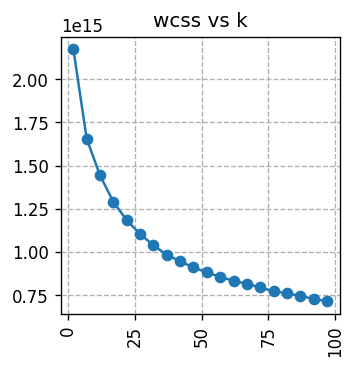

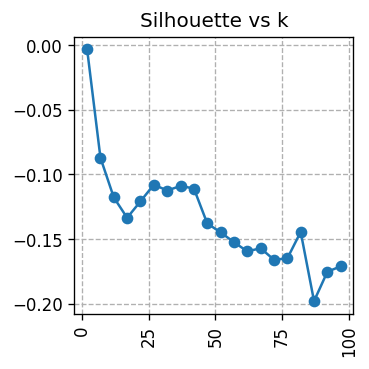

In [16]:
# plto WCSS & Silhouette to gauge at best K
plot_clust_metric(df_results, "wcss")
plot_clust_metric(df_results, "Silhouette")

## Cluster

In [ ]:
e_train = embeddings_train

(18305, 512)

In [41]:
# imports
from sklearn import preprocessing
from sklearn.cluster import KMeans

# variables
k = 53
k=35  # RNA-Seq RAW
# k = 63
do_cosine_dist = False
ALPHA = 0.01

# functions

km = KMeans(n_clusters=k, n_init=20, random_state=42)
if do_cosine_dist:
    
    km.fit(preprocessing.normalize(e_train))
else:
    km.fit(e_train)

k_labels = km.labels_

In [127]:
# cluster_purity(km.labels_, df_train["doid_id"].values)
cluster_purity(df_train["dataset"].values,km.labels_)

np.float64(0.5029226987161978)

In [17]:
len(e_train)

18305

In [18]:
# predict cluster for new data
if do_cosine_dist:
    test_pred_clusters = km.predict(preprocessing.normalize(e_test))
else:
    test_pred_clusters = km.predict(e_test)

In [19]:
clust_ord = np.array(sorted(list(set(k_labels))))

## Pseudo-Labels

### Generate Pseudo Labels

In [ ]:
# imports
import networkx as nx

# variables
ROOT = "DOID:4"
ROOT = "DOID:4"
SUB_ROOTS = ["DOID:7","DOID:2914","DOID:14566","DOID:162","DOID:0060072","DOID:0060071","DOID:0050686"]
# SUB_ROOTS = []


# functions

def get_multilab_true(doids:List, broad_doids:List, do_graph)->np.array:
    """return a len(doids) x len(broad_doids) matrix of 0's and 1's 
    depending on which broad doidease terms a given term belongs to
    """

    n_samples = len(doids)
    n_broad = len(broad_doids)

    Y = np.zeros((n_samples, n_broad), dtype=int)
    print(Y.shape)

    for i, doid in enumerate(doids):
        if doid not in do_graph:
            continue

        # ancestors = all broader terms
        ancestors = nx.ancestors(do_graph, doid)
        ancestors = list(ancestors)
        
        # include itself in the ancestors list 
        ancestors.append(doid)

        for j, broad in enumerate(broad_doids):
            if broad in ancestors:
                Y[i, j] = 1

    return Y

def make_ps_lab_pseudolabels(
    Y: np.ndarray,
):
    """
    Create a single pseudo-label per unique multi-label combination (row) in Y.

    Returns
    -------
    ps_lab : np.ndarray of shape (n_samples,)
        Integer ps_lab id per sample (0..n_unique-1)
    ps_lab_to_doid : Dict[int, List[str]]
        Mapping ps_lab id -> list of broad DOIDs included in that ps_lab
    onehot_to_ps_lab : Dict[Tuple[int, ...], int]
        Mapping from the row pattern (tuple of 0/1s) -> ps_lab id
    """
    # ensure int 0/1
    onehot_to_ps_lab: Dict[Tuple[int, ...], int] = dict()
    ps_lab_to_onehot: Dict[int, Tuple[int, ...]] = dict()
    ps_lab = np.empty(Y.shape[0], dtype=int)

    ps_id = 0   # pseudo label id
    for i in range(Y.shape[0]):
        key = tuple(Y[i].tolist())  # hashable representation of the multi-hot row
        if key not in onehot_to_ps_lab:
            onehot_to_ps_lab[key] = ps_id
            ps_id += 1
        ps_lab[i] = onehot_to_ps_lab[key]
    
    ps_lab_to_onehot = {v:k for k,v in onehot_to_ps_lab.items()}
    
    return ps_lab, ps_lab_to_onehot, onehot_to_ps_lab

# define top DOID terms to use
top_doid_terms = list(set(do_graph.successors(ROOT)))

# add successor sub root terms
sub_levels = list()
for sub_root_i in SUB_ROOTS:
    sub_level = list(set(do_graph.successors(sub_root_i)))
    sub_levels.extend(sub_level)

top_doid_terms.extend(sub_levels)

# remove sub root terms
top_doid_terms = list(set(top_doid_terms)-set(SUB_ROOTS))

# train
fam_tr = get_multilab_true(df_train["doid_id"].to_list(),top_doid_terms, do_graph=do_graph)
ps_lab_tr, ps_lab_to_onehot, onehot_to_ps_lab = make_ps_lab_pseudolabels(fam_tr)

# test
fam_ts = get_multilab_true(df_test["doid_id"].to_list(),top_doid_terms, do_graph=do_graph)

# map doid -> pseudo label
doid_to_ps_lab = dict(zip(df_train["doid_id"].to_list(), [int(p) for p in ps_lab_tr]))
ps_lab_to_doid = dict()
for d, ps_lab in doid_to_ps_lab.items():
    if ps_lab not in ps_lab_to_doid:
        ps_lab_to_doid[int(ps_lab)] = list()
    ps_lab_to_doid[int(ps_lab)].append(d)

# get test keys 
ps_lab_ts = [onehot_to_ps_lab[tuple(y)] for y in fam_ts]

(11823, 43)
(3611, 43)


### Explore Pseudo Labels

([], [])

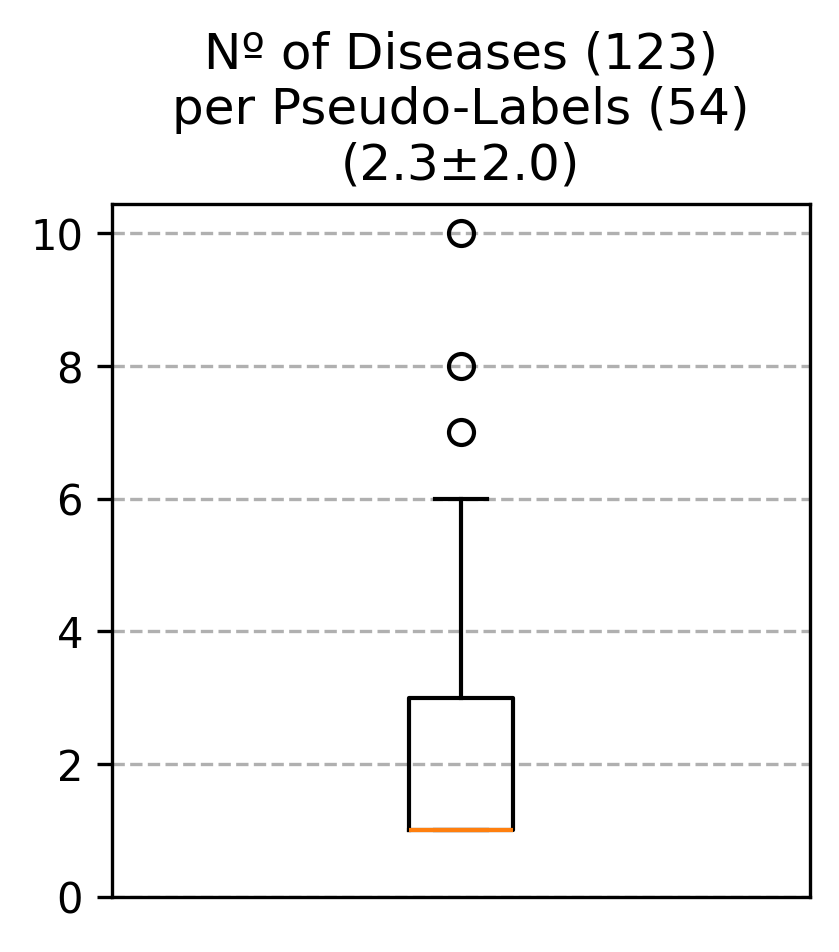

In [ ]:
dpi = 300
# plot nº of clusters per disease

n_dis_per_ps = [len(v) for v in ps_lab_to_doid.values()]
lab = f"{np.mean(n_dis_per_ps):.1f}±{np.std(n_dis_per_ps):.1f}"

plt.figure(figsize=(3, 3), dpi=dpi)
plt.title(f"Nº of Diseases ({df_train['doid_id'].nunique()})\nper Pseudo-Labels ({len(ps_lab_to_doid)})\n({lab})")
plt.boxplot([len(v) for v in ps_lab_to_doid.values()])
plt.grid(linestyle="--", axis="y")
plt.ylim(0,)
plt.xticks([])


In [ ]:
# print(sorted(ps_lab_to_doid.items(), key=lambda x: len(x[1]), reverse=True)[:5])

candidate = [v for v in ps_lab_to_doid.values() if len(v) == 10]
for d in [doid_to_term.get(d) for d in candidate[0]]:
    print(d)

amyotrophic lateral sclerosis
Parkinson's disease
Alzheimer's disease
Huntington's disease
keratoconus
Fuchs' endothelial dystrophy
multiple system atrophy
Riley-Day syndrome
spinal muscular atrophy
retinitis pigmentosa


### Run Enrichment 

In [ ]:
ALPHA = 0.01
ALPHA = 1

# enrichment analysis of crun_hypergeom_enrichmentluster labels!
df_k_enrich = run_hypergeom_enrichment(
    km.labels_, ps_lab_tr
)

# filter significant enrichments
df_k_enrich_sig = df_k_enrich[df_k_enrich["p_value"] < ALPHA]

# Create a map: {cluster_id: [list of enriched labels]}
clust_to_enr = dict()
for cluster_id in np.unique(df_k_enrich_sig["cluster"]):
    # Collect all disease DOIDs that are significantly enriched in this cluster
    enr_i = df_k_enrich_sig[df_k_enrich_sig["cluster"] == cluster_id][
        "disease"
    ].to_list()
    clust_to_enr[int(cluster_id)] = [int(e) for e in enr_i]


# now we want to map each cluster to diseases within that cluster with the enriched pseudo-label
clust_to_dis = dict()
clust_to_enr_dis = dict()
for cluster_id, dis_i in zip(km.labels_, df_train["doid_id"].to_list()):
    cluster_id = int(cluster_id)
    if cluster_id not in clust_to_dis:
        clust_to_dis[cluster_id] = set()
        clust_to_enr_dis[cluster_id] = set()
    
    clust_to_dis[cluster_id].add(dis_i)

    if doid_to_ps_lab.get(dis_i) in clust_to_enr.get(cluster_id):
        clust_to_enr_dis[cluster_id].add(dis_i)


### Cluster Validation

In [ ]:
def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)


n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{len(set(ps_lab_tr))}'
_n_uniq_dis = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_uniq_dis.mean():.1f}±{_n_uniq_dis.std():.1f}"
_n_clust = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust.mean():.1f}±{_n_clust.std():.1f}"


# nº of unique disease
n_uniq_dis = f'{df_k_enrich["disease"].nunique()}/{len(set(ps_lab_tr))}'
n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{len(set(ps_lab_tr))}'

# nº of diseases per cluster
_n_dis_per_clust = df_k_enrich.groupby("cluster")["disease"].nunique()
n_dis_per_clust = f"{_n_dis_per_clust.mean():.1f}±{_n_dis_per_clust.std():.1f}"

_n_enr_per_clust = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_enr_per_clust.mean():.1f}±{_n_enr_per_clust.std():.1f}"

# nº if cluster per disease
_n_clust_per_dis = df_k_enrich.groupby("disease")["cluster"].nunique()
n_clust_per_dis = f"{_n_clust_per_dis.mean():.1f}±{_n_clust_per_dis.std():.1f}"

_n_clust_per_enr = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust_per_enr.mean():.1f}±{_n_clust_per_enr.std():.1f}"

# mask ENRICHED DISEASES
mask = list()
for i in tqdm(range(len(df_train))):
    label_i = k_labels[i]
    dis_i = df_train["doid_id"].to_list()[i]

    # is this disease ENRICHED in this cluster?
    if doid_to_ps_lab[dis_i] in clust_to_enr.get(label_i):
        mask.append(True)
    else:
        mask.append(False)

print(f"Nº of masked diseases {np.sum(mask)}")
true_labels = np.array(df_train["doid_id"].to_list())
true_ps_lab = np.array([doid_to_ps_lab.get(t) for t in true_labels])

k_labels = np.array(k_labels)

# store in datafram
df_k_res = pd.DataFrame(
    [
        {
            "Clustering": "k",
            "Nº Samples": len(k_labels),
            "Nº Clusters": len(set(k_labels)),
            "Max Cluster Size": max(Counter(k_labels).values()),
            "Silhouette": f'{silhouette_score(e_train,k_labels.astype(int), metric="cosine"):.3f}',
            "Cluster Purity": f"{cluster_purity(true_ps_lab, k_labels):.3}",
            "Nº unique Enriched Diseases": n_uniq_dis,
            "Nº Enr. per Clust.": n_dis_per_clust,
            "Nº Clust. per Enr.": n_clust_per_dis,
            
        },
        {
            "Clustering": "k-enriched",
            "Nº Samples": len(k_labels[mask]),
            "Nº Clusters": len(set(k_labels[mask])),
            "Max Cluster Size": max(Counter(k_labels[mask]).values()),
            "Silhouette": f'{silhouette_score(e_train[mask],k_labels.astype(int)[mask], metric="cosine"):.3f}',
            "Cluster Purity": f'{cluster_purity(true_ps_lab[mask],k_labels[mask]):.3}',
            "Nº unique Enriched Diseases": n_uniq_enr,
            "Nº Enr. per Clust.": n_enr_per_clust,
            "Nº Clust. per Enr.": n_clust_per_enr,
        }


    ]
)

df_k_res

100%|██████████| 11823/11823 [00:01<00:00, 11664.81it/s]


Nº of masked diseases 11822


,Clustering,Nº Samples,Nº Clusters,Max Cluster Size,Silhouette,Cluster Purity,Nº unique Enriched Diseases,Nº Enr. per Clust.,Nº Clust. per Enr.
0,k,11823,63,711,0.561,0.839,54/54,5.7±3.3,6.6±5.4
1,k-enriched,11822,63,711,0.561,0.839,54/54,5.6±3.3,6.6±5.4


In [ ]:
df_k_res

,Clustering,Nº Samples,Nº Clusters,Max Cluster Size,Silhouette,Cluster Purity,Nº unique Enriched Diseases,Nº Enr. per Clust.,Nº Clust. per Enr.
0,k,11823,63,711,0.561,0.839,54/54,5.7±3.3,6.6±5.4
1,k-enriched,11822,63,711,0.561,0.839,54/54,5.6±3.3,6.6±5.4


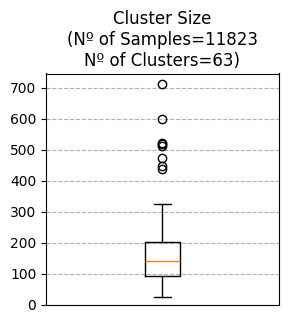

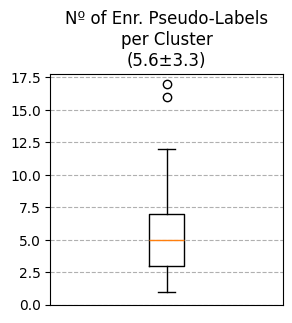

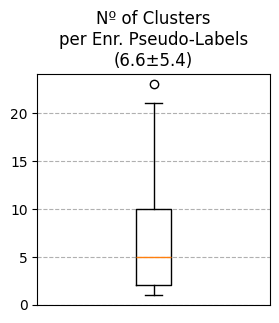

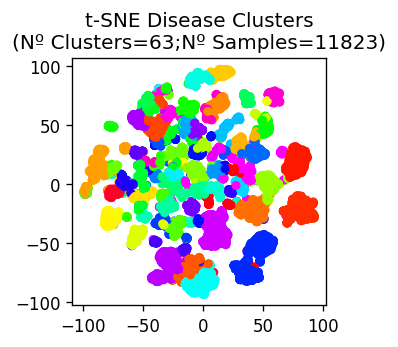

In [ ]:
dpi=100
plot_nclusters(k_labels, dpi)

# plot nº of enriched diseases per cluster
plt.figure(figsize=(3, 3), dpi=dpi)
plt.title(f"Nº of Enr. Pseudo-Labels\nper Cluster\n({n_enr_per_clust})")
plt.boxplot(_n_enr_per_clust)
plt.grid(linestyle="--", axis="y")
plt.ylim(0,)
plt.xticks([])

# plot nº of clusters per disease
plt.figure(figsize=(3, 3), dpi=dpi)
plt.title(f"Nº of Clusters\nper Enr. Pseudo-Labels\n({n_clust_per_enr})")
plt.boxplot(_n_clust_per_enr)
plt.grid(linestyle="--", axis="y")
plt.ylim(0,)
plt.xticks([])

# t-SNE
plot_reduced_emb(
    tsne_emb,
    k_labels,
    title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(k_labels))};Nº Samples={len(e_train)})",
)

In [ ]:
from itertools import combinations

# Semantic Similarity Validation
# ref: Clustering rare diseases within an ontology-enriched knowledge graph
# sample 100 x sets of average cluster size and check average pairwise semantic similarity
# then perform one way t-student test to check statistical significance to statistically 
# evaluate the difference in the mean average semantic similarity between the disease clusters

# real cluster semantic similarity
ss_cluster = list()
n_diseases = list()
clust_to_ss = dict()

flatten = lambda x : [x_i for x_sub in x for x_i in x_sub]

for c_i, enr_i in clust_to_enr_dis.items():

    n_diseases.append(len(enr_i))

    if len(enr_i)==1:
        continue
    
    _ss_clust = list()
    for d1, d2 in combinations(enr_i, 2):
        _lin_sim = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]
        _ss_clust.append(_lin_sim)

    clust_to_ss[c_i] = float(np.mean(_ss_clust))
    ss_cluster.append(_ss_clust)

# random cluster semantic similarity
mean_clust_size = int(round(np.mean(n_diseases)))

rnd_ss_cluster = list()
for _ in tqdm(range(10)):
    for _ in range(len(clust_to_enr)):
        # pick N random diseases
        _dis_samp = np.random.choice(dis_ord, size=mean_clust_size, replace=False)
        
        _ss_clust = list()
        for d1, d2 in combinations(_dis_samp, 2):
            _lin_sim = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]
            _ss_clust.append(_lin_sim)

        rnd_ss_cluster.append(_ss_clust)


100%|██████████| 10/10 [00:20<00:00,  2.03s/it]


Student’s t-test (one-sided, real > random): t = 17.551, p = 0.0000


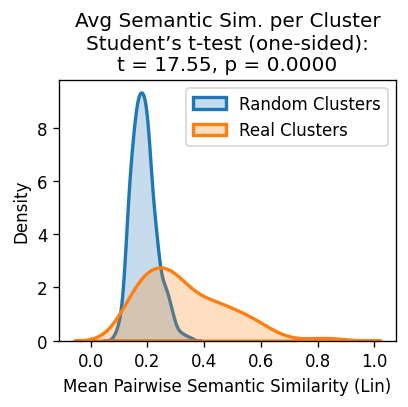

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

dpi = 120

# # random cluster semantic similarity
# mean_clust_size = int(round(np.mean([len(v) for v in clust_to_enr.values()])))

# rnd_ss_cluster = list()
# for _ in tqdm(range(100)):
#     for _ in range(len(clust_to_enr)):
#         # pick N random diseases
#         _dis_samp = np.random.choice(dis_ord, size=mean_clust_size, replace=False)

#         _ss_clust = list()
#         for d1, d2 in combinations(_dis_samp, 2):
#             _lin_sim = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]
#             _ss_clust.append(_lin_sim)

#         rnd_ss_cluster.append(_ss_clust)

# Statistical test on per-cluster average similarities
real_avgs = [float(np.mean(x)) for x in ss_cluster]
rand_avgs = [float(np.mean(x)) for x in rnd_ss_cluster]

t_stat, p_val_two_sided = ttest_ind(real_avgs, rand_avgs, equal_var=True)
p_val_one_sided = p_val_two_sided / 2 if t_stat > 0 else 1.0

print(f"Student’s t-test (one-sided, real > random): t = {t_stat:.3f}, p = {p_val_one_sided:.4f}")

# Plot KDEs
plt.figure(figsize=(3.5, 3.5), dpi =dpi)
sns.kdeplot(rand_avgs, fill=True, label='Random Clusters', linewidth=2)
sns.kdeplot(real_avgs, fill=True, label='Real Clusters', linewidth=2)

# Title with test statistic
plt.title(f'Avg Semantic Sim. per Cluster\nStudent’s t-test (one-sided):\nt = {t_stat:.2f}, p = {p_val_one_sided:.4f}')
plt.xlabel('Mean Pairwise Semantic Similarity (Lin)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

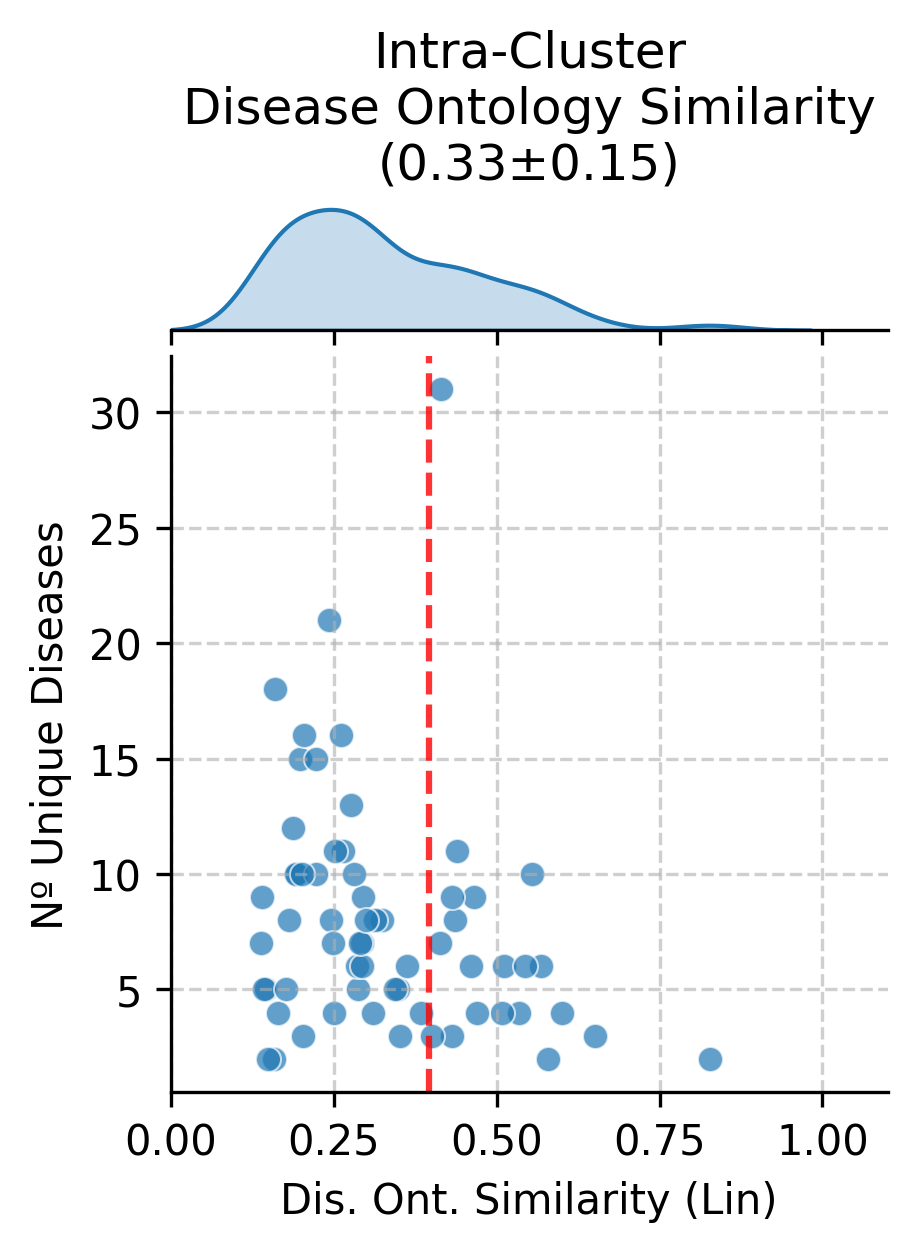

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_cluster_sim(x:np.array, y:np.array, title:str="",dpi:int=120)->None:

    # sns.set(style="white")
    # plt.figure(dpi=300)

    g = sns.JointGrid(
        x=x,
        y=y,
        height=3.5,
        xlim=(-0,1.1),
    )
    g.fig.set_dpi(dpi)
    # Center scatter
    g.plot_joint(
        sns.scatterplot,
        alpha=0.7
    )

    # KDE only for X (top)
    sns.kdeplot(
        x=x,
        ax=g.ax_marg_x,
        fill=True,
        bw_adjust=0.8
    )

    # Remove Y marginal completely
    g.ax_marg_y.remove()
    # Turn grid ON for the main (joint) axis
    g.ax_joint.grid(
        True,
        which="both",
        linestyle="--",
        # linewidth=0.7,
        alpha=0.6
    )

    # related/unrelated threshold line
    g.ax_joint.axvline(
    x=0.396,
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    color="red"
    )

    # Labels
    g.set_axis_labels("Dis. Ont. Similarity (Lin)", "Nº Unique Diseases")


    plt.title(title)
    plt.show()

x = [clust_to_ss.get(c) for c in clust_ord if c in clust_to_ss.keys()]
y = [len(clust_to_enr_dis.get(c)) for c in clust_ord if len(clust_to_enr_dis.get(c))>1]

plot_cluster_sim(x,y, 
                 title=f"Intra-Cluster\nDisease Ontology Similarity\n({np.mean(x):.2f}±{np.std(x):.2f})",
                 dpi=300)


In [ ]:
print(sorted(clust_to_ss.items(), key=lambda x:x[1])[:10])
print(sorted(clust_to_enr_dis.items(), key=lambda x:len(x[1]), reverse=True)[:10])
for d in [doid_to_term.get(d) for d in clust_to_enr_dis[39]]:
    print(d)

[(1, 0.1376337355061436), (37, 0.14038900390257356), (42, 0.14289179287495296), (41, 0.14518218613390982), (36, 0.1493659001009933), (13, 0.1586984491916765), (47, 0.15958224224628115), (8, 0.16462572873967654), (48, 0.17734131412381288), (49, 0.18094784588838214)]
[(59, {'DOID:11934', 'DOID:4007', 'DOID:3969', 'DOID:769', 'DOID:2526', 'DOID:10286', 'DOID:3907', 'DOID:5409', 'DOID:3748', 'DOID:1749', 'DOID:4905', 'DOID:3459', 'DOID:552', 'DOID:289', 'DOID:2394', 'DOID:5015', 'DOID:5517', 'DOID:3498', 'DOID:3908', 'DOID:3910', 'DOID:4450', 'DOID:1520', 'DOID:3717', 'DOID:0080199', 'DOID:4074', 'DOID:0081087', 'DOID:13922', 'DOID:1909', 'DOID:684', 'DOID:3068', 'DOID:3083'}), (44, {'DOID:2377', 'DOID:3070', 'DOID:9970', 'DOID:769', 'DOID:11963', 'DOID:10286', 'DOID:3748', 'DOID:4905', 'DOID:552', 'DOID:848', 'DOID:3310', 'DOID:14330', 'DOID:332', 'DOID:3905', 'DOID:7148', 'DOID:12858', 'DOID:9074', 'DOID:12704', 'DOID:10652', 'DOID:684', 'DOID:3068'}), (47, {'DOID:11934', 'DOID:12858', '

In [ ]:
clust_to_enr[38]

[33, 38, 27, 49, 7]

### Performance PS-Label & Broad Family

In [ ]:
# imports
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# variables
avg = "micro"
lin_thrs  = [0.396, 0.6, 0.8, 1]
# functions
def precision_recall_set(y_true, y_pred_sets, N):

    precisions = list()
    recalls = list()

    for t, P in zip(y_true, y_pred_sets):
        P = set(P)

        if len(P) == 0:
            precisions.append(0.0)
            recalls.append(0.0)
            continue

        if t in P:
            precisions.append(1.0 / len(P))
            recalls.append(1.0)
        else:
            precisions.append(0.0)
            recalls.append(0.0)


    return float(np.mean(precisions)), float(np.mean(recalls))

# map predicted clusters to pseudo-labels!
pred_ps_lab_ts = [clust_to_enr.get(c) for c in test_pred_clusters]   # test pseudo labels!


# Generate onehot for pseudo-label prediction
ps_lab_ord = np.array(sorted(ps_lab_to_doid.keys()))

ps_lab_onehot_ts = list()
for ps_i in ps_lab_ts:
    ps_lab_onehot_ts.append([1 if ps == ps_i else 0 for ps in ps_lab_ord])
ps_lab_onehot_ts = np.array(ps_lab_onehot_ts)

pred_ps_lab_onehot_ts = list()

for ps_lab in pred_ps_lab_ts:
    _one_hot = list()
    _one_hot.append([1 if d in ps_lab else 0 for d in ps_lab_ord])
    
    # merge one hot encoding into a single one!
    _one_hot = np.array(_one_hot)
    pred_ps_lab_onehot_ts.append(_one_hot.sum(axis=0).astype(bool).astype(int))

pred_ps_lab_onehot_ts = np.array(pred_ps_lab_onehot_ts)


# map pseudo-labels to broad doid terms one hot encodings!
pred_fam_ts = list()
for ps_lab in pred_ps_lab_ts:
    _one_hot = list()
    for ps_i in ps_lab:
        _one_hot.append(ps_lab_to_onehot[ps_i])
    
    # merge one hot encoding into a single one!
    _one_hot = np.array(_one_hot)
    pred_fam_ts.append(_one_hot.sum(axis=0).astype(bool).astype(int))

pred_fam_ts = np.array(pred_fam_ts)

# doid-label precision & recall
data_ps_perf = list()
data_ps_perf.append({"category":"ps label",
                        "roc_auc":f"{roc_auc_score(ps_lab_onehot_ts, pred_ps_lab_onehot_ts, average=avg):.3f}",
                        "ap":f"{average_precision_score(ps_lab_onehot_ts, pred_ps_lab_onehot_ts, average=avg):.3f}",
                        "precision":f"{precision_score(ps_lab_onehot_ts, pred_ps_lab_onehot_ts, average=avg):.3f}",
                        "recall":f"{recall_score(ps_lab_onehot_ts, pred_ps_lab_onehot_ts, average=avg):.3f}",
                        "hit":f"{recall_score(np.ones(len(df_test)), (ps_lab_onehot_ts & pred_ps_lab_onehot_ts).sum(axis=1)>0):.3f}"})

data_ps_perf.append({"category":"family",
                        "roc_auc":f"{roc_auc_score(fam_ts, pred_fam_ts, average=avg):.3f}",
                        "ap":f"{average_precision_score(fam_ts, pred_fam_ts, average=avg):.3f}",
                        "precision":f"{precision_score(fam_ts, pred_fam_ts, average=avg):.3f}",
                        "recall":f"{recall_score(fam_ts, pred_fam_ts, average=avg):.3f}",
                        "hit":f"{recall_score(np.ones(len(df_test)), (fam_ts & pred_fam_ts).sum(axis=1)>0):.3f}"})


pd.DataFrame(data_ps_perf)

,category,roc_auc,ap,precision,recall,hit
0,ps label,0.804,0.086,0.112,0.716,0.716
1,family,0.853,0.224,0.251,0.860,0.898


In [ ]:
# variables
avg = "micro"

# store rndom performance
rnd_roc_ps = list()
rnd_ap_ps = list()
rnd_prec_ps = list()
rnd_rec_ps = list()
rnd_hit_ps = list()
rnd_roc_fm = list()
rnd_ap_fm = list()
rnd_prec_fm = list()
rnd_rec_fm = list()
rnd_hit_fm = list()

for i in range(100):
    rng = np.random.default_rng(i)
    _rnd_clust = rng.choice(clust_ord, size=len(df_test), replace=True)

    # map predicted clusters to pseudo-labels!
    _rnd_lab = [clust_to_enr.get(c) for c in _rnd_clust]   # test pseudo labels!

    _rnd_ps_lab_ts = list()
    for ps_lab in _rnd_lab:
        _one_hot = list()
        _one_hot.append([1 if d in ps_lab else 0 for d in ps_lab_ord])
        
        # merge one hot encoding into a single one!
        _one_hot = np.array(_one_hot)
        _rnd_ps_lab_ts.append(_one_hot.sum(axis=0).astype(bool).astype(int))

    _rnd_ps_lab_ts = np.array(_rnd_ps_lab_ts)


    # map pseudo-labels to broad doid terms one hot encodings!
    _rnd_fam_ts = list()
    for ps_lab in _rnd_lab:
        _one_hot = list()
        for ps_i in ps_lab:
            _one_hot.append(ps_lab_to_onehot[ps_i])
        
        # merge one hot encoding into a single one!
        _one_hot = np.array(_one_hot)
        _rnd_fam_ts.append(_one_hot.sum(axis=0).astype(bool).astype(int))

    _rnd_fam_ts = np.array(_rnd_fam_ts)

    # store values
    rnd_roc_ps.append(roc_auc_score(ps_lab_onehot_ts, _rnd_ps_lab_ts, average=avg))
    rnd_ap_ps.append(average_precision_score(ps_lab_onehot_ts, _rnd_ps_lab_ts, average=avg))
    rnd_prec_ps.append(precision_score(ps_lab_onehot_ts, _rnd_ps_lab_ts, average=avg))
    rnd_rec_ps.append(recall_score(ps_lab_onehot_ts, _rnd_ps_lab_ts, average=avg))
    rnd_hit_ps.append(recall_score(np.ones(len(df_test)), (ps_lab_onehot_ts & _rnd_ps_lab_ts).sum(axis=1)>0))
    rnd_roc_fm.append(roc_auc_score(fam_ts, _rnd_fam_ts, average=avg))
    rnd_ap_fm.append(average_precision_score(fam_ts, _rnd_fam_ts, average=avg))
    rnd_prec_fm.append(precision_score(fam_ts, _rnd_fam_ts, average=avg))
    rnd_rec_fm.append(recall_score(fam_ts, _rnd_fam_ts, average=avg))
    rnd_hit_fm.append(recall_score(np.ones(len(df_test)), (fam_ts & _rnd_fam_ts).sum(axis=1)>0))


# doid-label precision & recall
data_rnd_ps_perf = list()
data_rnd_ps_perf.append({"category":"ps label",
                        "roc_auc":f"{np.mean(rnd_roc_ps):.3f}",
                        "ap":f"{np.mean(rnd_ap_ps):.3f}",
                        "precision":f"{np.mean(rnd_prec_ps):.3f}",
                        "recall":f"{np.mean(rnd_rec_ps):.3f}",
                        "hit":f"{np.mean(rnd_hit_ps):.3f}"})

data_rnd_ps_perf.append({"category":"family",
                        "roc_auc":f"{np.mean(rnd_roc_fm):.3f}",
                        "ap":f"{np.mean(rnd_ap_fm):.3f}",
                        "precision":f"{np.mean(rnd_prec_fm):.3f}",
                        "recall":f"{np.mean(rnd_rec_fm):.3f}",
                        "hit":f"{np.mean(rnd_hit_fm):.3f}"})


pd.DataFrame(data_rnd_ps_perf)

,category,roc_auc,ap,precision,recall,hit
0,ps label,0.530,0.020,0.029,0.164,0.164
1,family,0.608,0.083,0.128,0.365,0.563


In [ ]:
_rnd_lab

[[15, 2, 17],
 [9, 4, 12, 10],
 [20, 44, 26, 0, 52, 28, 33, 4, 40, 25, 19, 2],
 [12, 38, 22, 2, 16, 26, 18],
 [22, 11, 12],
 [8, 35, 3, 4],
 [24, 14, 29, 27, 42, 16, 28, 5, 6, 31, 33, 1, 13, 19, 7, 4],
 [7, 42],
 [15, 2, 17],
 [33, 38, 27, 49, 7],
 [12, 49, 37, 9, 7, 10],
 [12, 38, 22, 2, 16, 26, 18],
 [2, 15, 32],
 [13, 24, 6, 29, 14, 21],
 [15, 2, 17],
 [4, 9, 6],
 [4, 2, 8, 15, 38, 33, 19, 10],
 [22, 0],
 [3, 31, 5],
 [33, 38, 27, 49, 7],
 [23, 37, 43, 10, 12],
 [2, 42, 22, 17, 5],
 [13, 24, 6, 29, 14, 21],
 [18, 37, 35],
 [29, 32, 46, 25, 0, 17, 4, 10, 2],
 [12, 49, 37, 9, 7, 10],
 [23, 37, 43, 10, 12],
 [15, 2],
 [14, 16, 19, 22, 5, 6],
 [20, 44, 41, 25, 19, 52, 2, 12],
 [4, 6],
 [4, 2, 8, 15, 38, 33, 19, 10],
 [16, 48, 47, 8, 26],
 [2, 42, 22, 17, 5],
 [14, 16, 19, 22, 5, 6],
 [17, 40, 46, 0, 10, 19, 25, 26, 3],
 [10, 26, 7, 25],
 [16, 48, 47, 8, 26],
 [16, 48, 47, 8, 26],
 [5, 16, 29, 14, 6],
 [2, 20, 29, 7, 17],
 [13, 24, 6, 29, 14, 21],
 [4, 2, 8, 15, 38, 33, 19, 10],
 [2, 29,

In [ ]:
ps_lab

[16, 48, 47, 8, 26]

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42],
 [Text(0, 0, 'primary immunodeficiency disease'),
  Text(1, 0, 'nervous system disease'),
  Text(2, 0, 'cell type cancer'),
  Text(3, 0, 'respiratory system disease'),
  Text(4, 0, 'musculoskeletal system disease'),
  Text(5, 0, 'gastrointestinal system disease'),
  Text(6, 0, 'genetic disease'),
  Text(7, 0, 'endocrine system disease'),
  Text(8, 0, 'cardiovascular system disease'),
  Text(9, 0, 'disease of metabolism'),
  Text(10, 0, 'gastrointestinal system cancer'),
  Text(11, 0, 'endocrine gland cancer'),
  Text(12, 0, 'respiratory system cancer'),
  Text(13, 0, 'hematologic cancer'),
  Text(14, 0, 'nervous system cancer'),
  Text(15, 0, 'hematopoietic system disease'),
  Text(16, 0, 'syndrome'),
  Text(17, 0, 'reproductive system disea

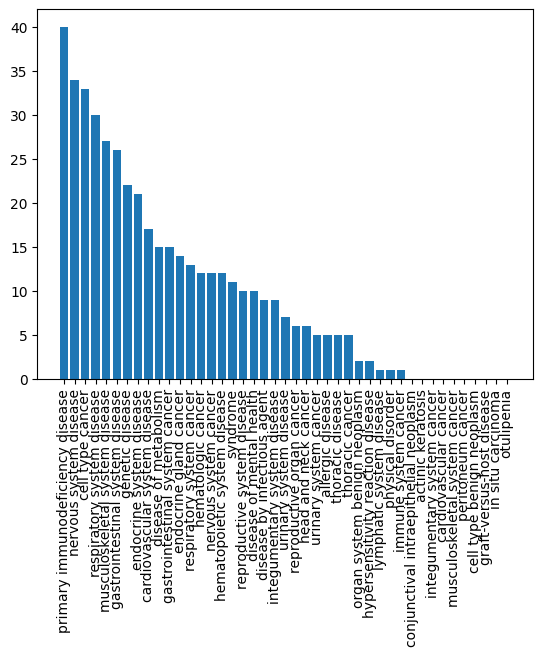

In [ ]:
# map each cluster to main enriched disease families
m_families = list()
for k,v in clust_to_enr.items():
    _one_hot = list()
    for ps in v:
        _one_hot.append(ps_lab_to_onehot.get(ps))
    
    _one_hot = (np.array(_one_hot).sum(axis=0)>0).astype(bool).astype(int)

    m_families.append(_one_hot)

m_families = np.array(m_families)

# count abundance of each family 
fam_count = m_families.sum(axis=0)

s_idxs = np.argsort(fam_count)[::-1]

plt.bar([doid_to_term.get(d) for d in np.array(top_doid_terms)[s_idxs]], fam_count[s_idxs])
# plt.bar(np.array(top_doid_terms)[s_idxs], fam_count[s_idxs])
plt.xticks(rotation=90)


### Performance Enriched Diseases

In [ ]:
# build matrix dis x dis w/ values of Ontology Similarity
dis_ord = dis_ord
m_lin_sim = np.zeros((len(dis_ord),len(dis_ord)))

# subset IC
for i, d1 in enumerate(dis_ord):
    for j, d2 in enumerate(dis_ord):
        if d1 == d2:
            m_lin_sim[i,j] = 1
        else:
            m_lin_sim[i,j] = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]

doid_to_lin = dict(zip(dis_ord, m_lin_sim))
lin_ts = np.array([doid_to_lin[d] for d in df_test["doid_id"]])
print("Shape lin_ts", lin_ts.shape)

Shape lin_ts (3611, 123)


In [ ]:

# imports
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# variables
avg = "micro"
data_dis_perf = list()
lin_thrs = [1, 0.8, 0.6, 0.396]

# functions

# map predicted clusters to doid-labels!
pred_doid_lab_ts = [clust_to_enr_dis.get(c) for c in test_pred_clusters]   # test doid labels!

pred_lin_ts = list()
for lab in pred_doid_lab_ts:
    pred_lin_ts.append([1 if d in lab  else 0 for d in dis_ord])
pred_lin_ts = np.array(pred_lin_ts)

# doid-label precision & recall
for lin_thr in lin_thrs:
    data_dis_perf.append({"lin_thr":lin_thr,
                          "roc_auc":f"{roc_auc_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "ap":f"{average_precision_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "precision":f"{precision_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "recall":f"{recall_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "hit":f"{recall_score(np.ones(len(df_test)), (pred_lin_ts & (lin_ts>=lin_thr)).sum(axis=1)>0):.3f}"})

pd.DataFrame(data_dis_perf)

,lin_thr,roc_auc,ap,precision,recall,hit
0,1.000,0.575,0.012,0.025,0.221,0.221
1,0.800,0.636,0.043,0.089,0.339,0.556
2,0.600,0.593,0.088,0.189,0.249,0.753
3,0.396,0.562,0.247,0.475,0.172,0.880


In [ ]:
# variables
avg = "micro"

data_rand_dis_perf = list()
for lin_thr in tqdm(lin_thrs):

    # store random performance
    rnd_roc_onehot = list()
    rnd_ap_oneshot = list()
    rnd_prec_onehot = list()
    rnd_rec_onehot = list()
    rnd_rec_hits = list()

    for i in range(100):
        rng = np.random.default_rng(i)
        _rnd_clust = rng.choice(clust_ord, size=len(df_test), replace=True)

        # map predicted clusters to doideudo-labels!
        _rnd_lab = [clust_to_enr_dis.get(c) for c in _rnd_clust]   # test doideudo labels!

        _rnd_one_hot = list()
        for lab in _rnd_lab:
            _rnd_one_hot.append([1 if d in lab  else 0 for d in dis_ord])
        _rnd_one_hot = np.array( _rnd_one_hot)

        # multilabel
        _rnd_roc_auc = roc_auc_score(lin_ts>=lin_thr, _rnd_one_hot, average=avg)
        _onehot_prec = precision_score(lin_ts>=lin_thr,_rnd_one_hot, average=avg)
        _onehot_rec = recall_score(lin_ts>=lin_thr,_rnd_one_hot, average=avg)
        _rnd_hits = (_rnd_one_hot & (lin_ts>=lin_thr)).sum(axis=1)>0

        rnd_roc_onehot.append(_rnd_roc_auc)
        rnd_ap_oneshot.append(average_precision_score(lin_ts>=lin_thr, _rnd_one_hot, average=avg))
        rnd_prec_onehot.append(_onehot_prec)
        rnd_rec_onehot.append(_onehot_rec)
        rnd_rec_hits.append(recall_score(np.ones(len(df_test)), _rnd_hits))

    data_rand_dis_perf.append({"lin_thr":lin_thr,
                        "roc_auc":f"{np.mean(rnd_roc_onehot):.3f}",
                        "ap":f"{np.mean(rnd_ap_oneshot):.3f}",
                        "precision":f"{np.mean(rnd_prec_onehot):.3f}",
                        "recall":f"{np.mean(rnd_rec_onehot):.3f}",
                        "hit":f"{np.mean(rnd_rec_hits):.3f}"})


pd.DataFrame(data_rand_dis_perf)

100%|██████████| 4/4 [00:32<00:00,  8.22s/it]


,lin_thr,roc_auc,ap,precision,recall,hit
0,1.000,0.495,0.008,0.007,0.054,0.054
1,0.800,0.501,0.019,0.019,0.065,0.123
2,0.600,0.497,0.055,0.051,0.059,0.217
3,0.396,0.498,0.199,0.189,0.061,0.533


## Disease Labels

### Generate Disease Labels

In [69]:
# functions

def get_multilab_true(doids:List, broad_doids:List, do_graph)->np.array:
    """return a len(doids) x len(broad_doids) matrix of 0's and 1's 
    depending on which broad doidease terms a given term belongs to
    """

    n_samples = len(doids)
    n_broad = len(broad_doids)

    Y = np.zeros((n_samples, n_broad), dtype=int)
    print(Y.shape)

    for i, doid in enumerate(doids):
        if doid not in do_graph:
            continue

        # ancestors = all broader terms
        ancestors = nx.ancestors(do_graph, doid)
        ancestors = list(ancestors)
        
        # include itself in the ancestors list 
        ancestors.append(doid)

        for j, broad in enumerate(broad_doids):
            if broad in ancestors:
                Y[i, j] = 1

    return Y

# onehot_tr = get_multilab_true(df_train["doid_id"].to_list(), top_doid_terms, do_graph)
# doid_to_onehot = dict(zip(df_train["doid_id"].to_list(), onehot_tr))

### Run Enrichment

In [70]:
ALPHA = 0.01
# ALPHA = 1
# enrichment analysis of crun_hypergeom_enrichmentluster labels!
df_k_enrich = run_hypergeom_enrichment(
    km.labels_, df_train["doid_id"].to_list()
)

# filter significant enrichments
df_k_enrich_sig = df_k_enrich[df_k_enrich["p_value"] <= ALPHA]

# Create a map: {cluster_id: [list of enriched labels]}
clust_to_enr = dict()
for cluster_id in np.unique(df_k_enrich_sig["cluster"]):
    # Collect all disease DOIDs that are significantly enriched in this cluster
    diseases = df_k_enrich_sig[df_k_enrich_sig["cluster"] == cluster_id][
        "disease"
    ].to_list()
    clust_to_enr[int(cluster_id)] = [str(d) for d in diseases]


### Cluster Validation

In [72]:
def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)


n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{df_train["doid_id"].nunique()}'
_n_uniq_dis = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_uniq_dis.mean():.1f}±{_n_uniq_dis.std():.1f}"
_n_clust = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust.mean():.1f}±{_n_clust.std():.1f}"


# nº of unique disease
n_uniq_dis = f'{df_k_enrich["disease"].nunique()}/{df_train["doid_id"].nunique()}'
n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{df_train["doid_id"].nunique()}'

# nº of diseases per cluster
_n_dis_per_clust = df_k_enrich.groupby("cluster")["disease"].nunique()
n_dis_per_clust = f"{_n_dis_per_clust.mean():.1f}±{_n_dis_per_clust.std():.1f}"

_n_enr_per_clust = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_enr_per_clust.mean():.1f}±{_n_enr_per_clust.std():.1f}"

# nº if cluster per disease
_n_clust_per_dis = df_k_enrich.groupby("disease")["cluster"].nunique()
n_clust_per_dis = f"{_n_clust_per_dis.mean():.1f}±{_n_clust_per_dis.std():.1f}"

_n_clust_per_enr = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust_per_enr.mean():.1f}±{_n_clust_per_enr.std():.1f}"

# mask ENRICHED DISEASES
mask = list()
for i in tqdm(range(len(df_train))):
    label_i = k_labels[i]
    dis_i = df_train["doid_id"].to_list()[i]

    # is this disease ENRICHED in this cluster?
    if dis_i in clust_to_enr.get(label_i, []):
        mask.append(True)
    else:
        mask.append(False)

print(f"Nº of masked diseases {np.sum(mask)}")
true_labels = np.array(df_train["doid_id"].to_list())

k_labels = np.array(k_labels)

# store in datafram
df_k_res = pd.DataFrame(
    [
        {
            "Clustering": "k",
            "Nº Samples": len(k_labels),
            "Nº Clusters": len(set(k_labels)),
            "Max Cluster Size": max(Counter(k_labels).values()),
            "Silhouette": f'{silhouette_score(e_train,k_labels.astype(int), metric="cosine"):.3f}',
            "Cluster Purity": f"{cluster_purity(true_labels, k_labels):.3}",
            "Nº unique Enriched Diseases": n_uniq_dis,
            "Nº Dis. per Clust.": n_dis_per_clust,
            "Nº Clust. per Enr.": n_clust_per_dis,
            
        },
        {
            "Clustering": "k-enriched",
            "Nº Samples": len(k_labels[mask]),
            "Nº Clusters": len(set(k_labels[mask])),
            "Max Cluster Size": max(Counter(k_labels[mask]).values()),
            "Silhouette": f'{silhouette_score(e_train[mask],k_labels.astype(int)[mask], metric="cosine"):.3f}',
            "Cluster Purity": f'{cluster_purity(true_labels[mask],k_labels[mask]):.3}',
            "Nº unique Enriched Diseases": n_uniq_enr,
            "Nº Dis. per Clust.": n_enr_per_clust,
            "Nº Clust. per Enr.": n_clust_per_enr,
        }


    ]
)

df_k_res

100%|██████████| 18305/18305 [00:02<00:00, 7514.48it/s]


Nº of masked diseases 15502


,Clustering,Nº Samples,Nº Clusters,Max Cluster Size,Silhouette,Cluster Purity,Nº unique Enriched Diseases,Nº Dis. per Clust.,Nº Clust. per Enr.
0,k,18305,53,1150,0.505,0.571,124/124,10.2±5.7,4.4±5.5
1,k-enriched,15502,53,1147,0.544,0.663,124/124,4.8±3.2,2.0±2.3


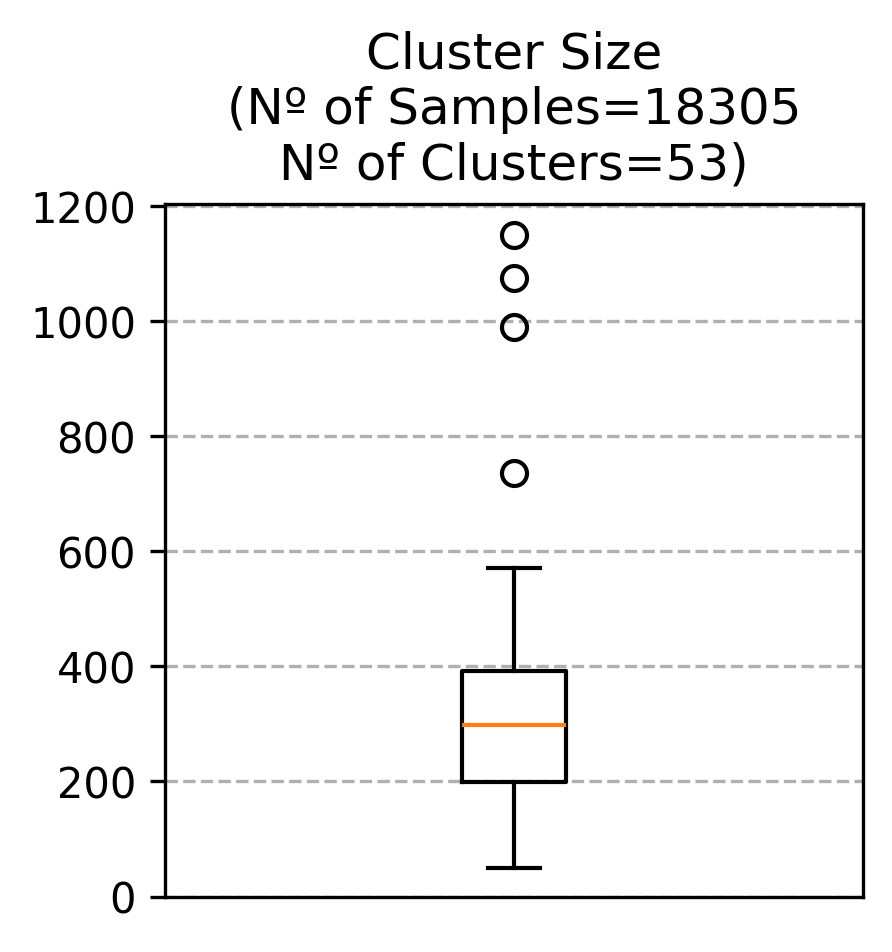

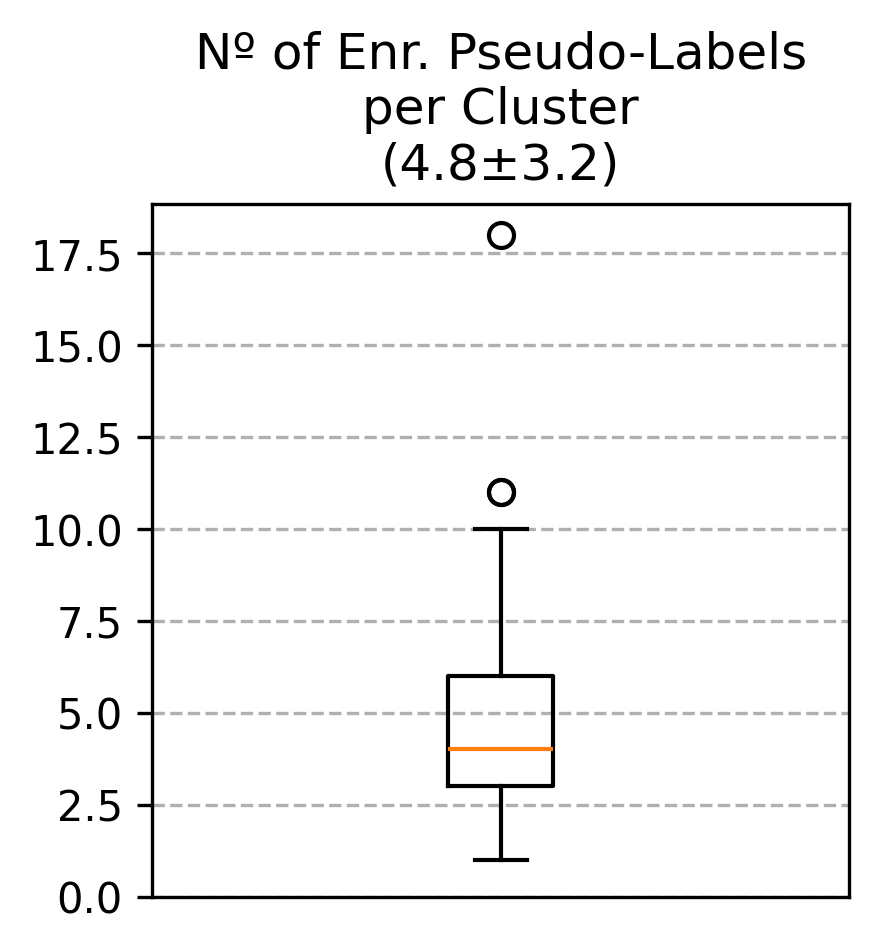

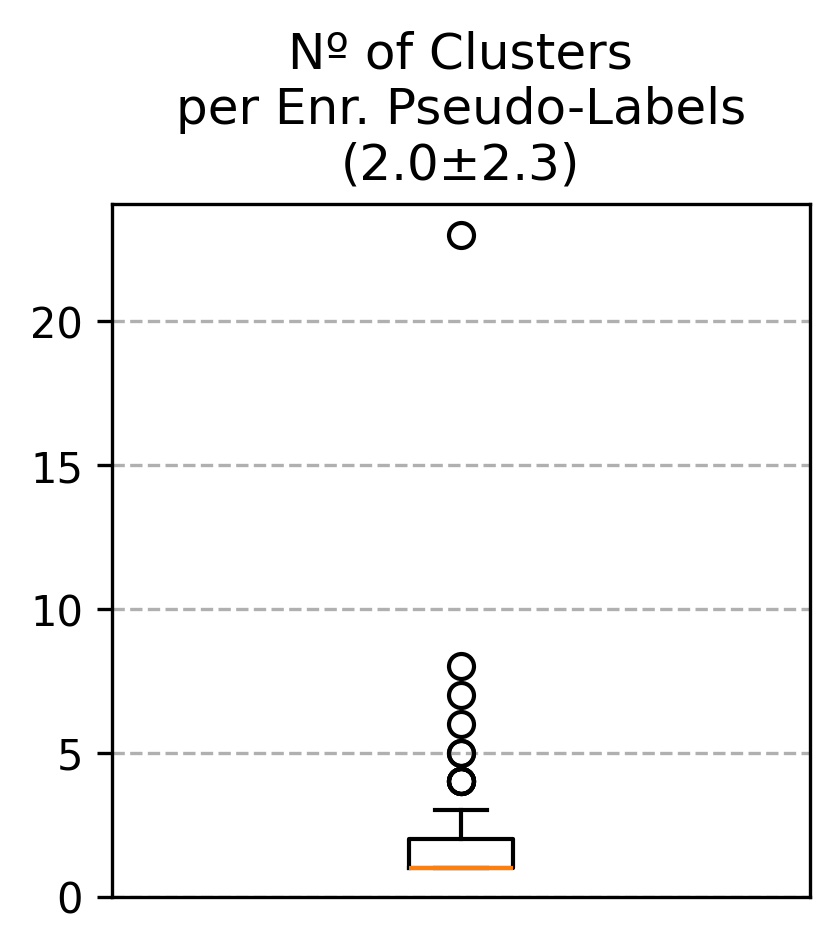

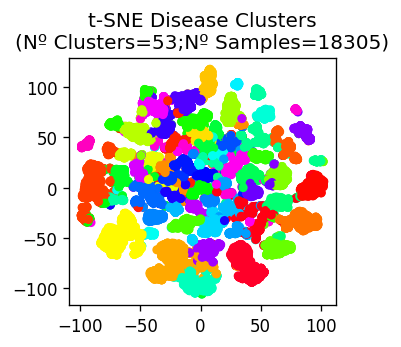

In [73]:
dpi=300
plot_nclusters(k_labels, dpi)

# plot nº of enriched diseases per cluster
plt.figure(figsize=(3, 3), dpi=dpi)
plt.title(f"Nº of Enr. Pseudo-Labels\nper Cluster\n({n_enr_per_clust})")
plt.boxplot(_n_enr_per_clust)
plt.grid(linestyle="--", axis="y")
plt.ylim(0,)
plt.xticks([])

# plot nº of clusters per disease
plt.figure(figsize=(3, 3), dpi=dpi)
plt.title(f"Nº of Clusters\nper Enr. Pseudo-Labels\n({n_clust_per_enr})")
plt.boxplot(_n_clust_per_enr)
plt.grid(linestyle="--", axis="y")
plt.ylim(0,)
plt.xticks([])

# t-SNE
plot_reduced_emb(
    tsne_emb,
    k_labels,
    title=f"t-SNE Disease Clusters\n(Nº Clusters={len(set(k_labels))};Nº Samples={len(e_train)})",
)

In [64]:
from itertools import combinations

# Semantic Similarity Validation
# ref: Clustering rare diseases within an ontology-enriched knowledge graph
# sample 100 x sets of average cluster size and check average pairwise semantic similarity
# then perform one way t-student test to check statistical significance to statistically 
# evaluate the difference in the mean average semantic similarity between the disease clusters

# real cluster semantic similarity
ss_cluster = list()
clust_to_ss = dict()
for c_i, enr_i in clust_to_enr.items():

    if len(enr_i)==1:
        continue
    
    _ss_clust = list()
    for d1, d2 in combinations(enr_i, 2):
        _lin_sim = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]
        _ss_clust.append(_lin_sim)

    clust_to_ss[c_i] = float(np.mean(_ss_clust))
    ss_cluster.append(_ss_clust)

# random cluster semantic similarity
mean_clust_size = int(round(np.mean([len(v) for v in clust_to_enr.values()])))

rnd_ss_cluster = list()
for _ in tqdm(range(100)):
    for _ in range(len(clust_to_enr)):
        # pick N random diseases
        _dis_samp = np.random.choice(dis_ord, size=mean_clust_size, replace=False)

        _ss_clust = list()
        for d1, d2 in combinations(_dis_samp, 2):
            _lin_sim = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]
            _ss_clust.append(_lin_sim)

        rnd_ss_cluster.append(_ss_clust)



IndexError: index 0 is out of bounds for axis 0 with size 0

Student’s t-test (one-sided, real > random): t = 23.299, p = 0.0000


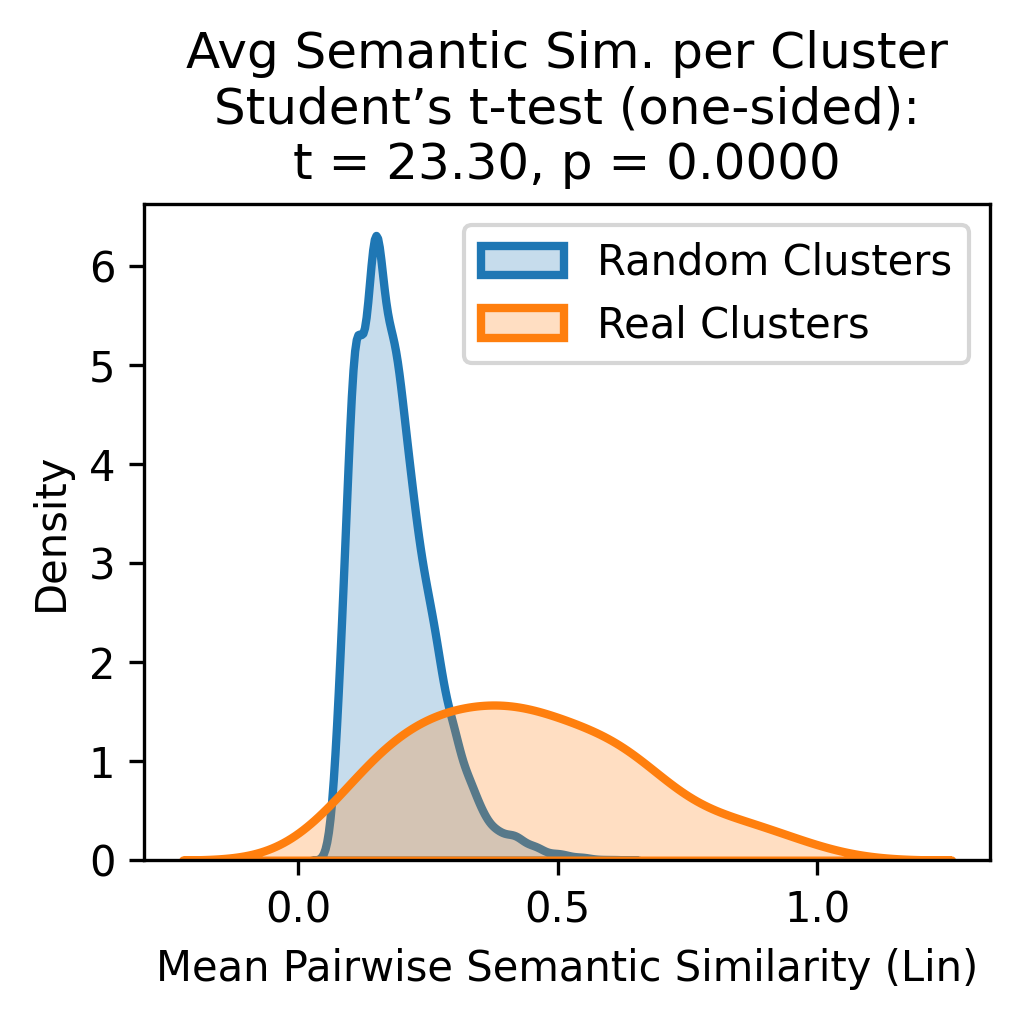

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

dpi = 300

# Statistical test on per-cluster average similarities
real_avgs = [float(np.mean(x)) for x in ss_cluster]
rand_avgs = [float(np.mean(x)) for x in rnd_ss_cluster]

t_stat, p_val_two_sided = ttest_ind(real_avgs, rand_avgs, equal_var=True)
p_val_one_sided = p_val_two_sided / 2 if t_stat > 0 else 1.0

print(f"Student’s t-test (one-sided, real > random): t = {t_stat:.3f}, p = {p_val_one_sided:.4f}")

# Plot KDEs
plt.figure(figsize=(3.5, 3.5), dpi =dpi)
sns.kdeplot(rand_avgs, fill=True, label='Random Clusters', linewidth=2)
sns.kdeplot(real_avgs, fill=True, label='Real Clusters', linewidth=2)

# Title with test statistic
plt.title(f'Avg Semantic Sim. per Cluster\nStudent’s t-test (one-sided):\nt = {t_stat:.2f}, p = {p_val_one_sided:.4f}')
plt.xlabel('Mean Pairwise Semantic Similarity (Lin)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec



c_k_dis_lin = dict()
c_k_dis_size = dict()
for alpha in [1,0.05]:
    c_k_dis_lin[alpha] = list()
    c_k_dis_size[alpha] = list()
    for k in tqdm(df_k_enrich["cluster"].unique()):
        
        # get diseases from cluster
        diseases_i = df_k_enrich.query("(cluster==@k) & (p_value<@alpha)")["disease"].to_list()

        c_k_dis_size[alpha].append(len(diseases_i))
        if len(diseases_i)==1:
            
            c_k_dis_lin[alpha].append(1)
            continue

        # compute lin score for these pairs
        pairs_i = list(itertools.combinations(diseases_i, 2))
        lin_i = [lin_map[d1][d2] for d1, d2 in pairs_i]
        c_k_dis_lin[alpha].append(np.mean(lin_i))

    c_k_dis_lin[alpha] = np.array(c_k_dis_lin[alpha]) 
    c_k_dis_size[alpha] = np.array(c_k_dis_size[alpha])

100%|██████████| 63/63 [00:00<00:00, 1512.95it/s]


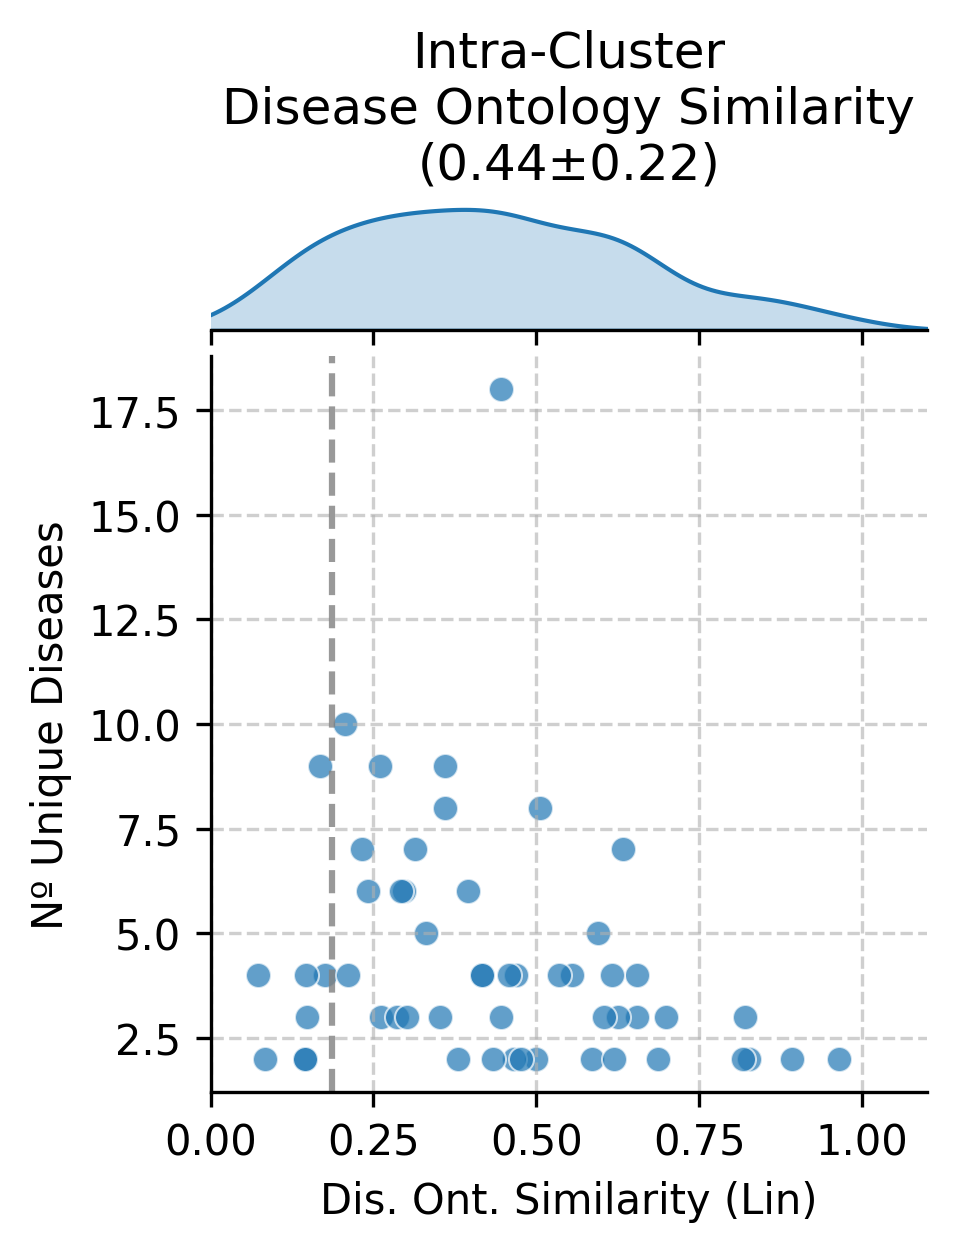

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_cluster_sim(x:np.array, y:np.array, title:str="",dpi:int=120)->None:

    # sns.set(style="white")
    # plt.figure(dpi=300)

    g = sns.JointGrid(
        x=x,
        y=y,
        height=3.5,
        xlim=(-0,1.1),
    )
    g.fig.set_dpi(dpi)
    # Center scatter
    g.plot_joint(
        sns.scatterplot,
        alpha=0.7
    )

    # KDE only for X (top)
    sns.kdeplot(
        x=x,
        ax=g.ax_marg_x,
        fill=True,
        bw_adjust=0.8
    )

    # Remove Y marginal completely
    g.ax_marg_y.remove()
    # Turn grid ON for the main (joint) axis
    g.ax_joint.grid(
        True,
        which="both",
        linestyle="--",
        # linewidth=0.7,
        alpha=0.6
    )

    # related/unrelated threshold line
    g.ax_joint.axvline(
    x=np.mean(rand_avgs),
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    color="grey"
    )

    # Labels
    g.set_axis_labels("Dis. Ont. Similarity (Lin)", "Nº Unique Diseases")


    plt.title(title)
    plt.show()

x = [clust_to_ss.get(c) for c in clust_ord if c in clust_to_ss.keys()]
y = [len(clust_to_enr.get(c)) for c in clust_ord if len(clust_to_enr.get(c, []))>1]

plot_cluster_sim(x,y, 
                 title=f"Intra-Cluster\nDisease Ontology Similarity\n({np.mean(x):.2f}±{np.std(x):.2f})",
                 dpi=300)


In [ ]:
def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)


n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{df_train["doid_id"].nunique()}'
_n_uniq_dis = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_uniq_dis.mean():.1f}±{_n_uniq_dis.std():.1f}"
_n_clust = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust.mean():.1f}±{_n_clust.std():.1f}"


# nº of unique disease
n_uniq_dis = f'{df_k_enrich["disease"].nunique()}/{df_train["doid_id"].nunique()}'
n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{df_train["doid_id"].nunique()}'

# nº of diseases per cluster
_n_dis_per_clust = df_k_enrich.groupby("cluster")["disease"].nunique()
n_dis_per_clust = f"{_n_dis_per_clust.mean():.1f}±{_n_dis_per_clust.std():.1f}"

_n_enr_per_clust = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_enr_per_clust.mean():.1f}±{_n_enr_per_clust.std():.1f}"

# nº if cluster per disease
_n_clust_per_dis = df_k_enrich.groupby("disease")["cluster"].nunique()
n_clust_per_dis = f"{_n_clust_per_dis.mean():.1f}±{_n_clust_per_dis.std():.1f}"

_n_clust_per_enr = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust_per_enr.mean():.1f}±{_n_clust_per_enr.std():.1f}"

# mask ENRICHED DISEASES
mask = list()
for i in tqdm(range(len(df_train))):
    label_i = k_labels[i]
    dis_i = df_train["doid_id"].to_list()[i]

    # is this disease ENRICHED in this cluster?
    if dis_i in clust_to_enr.get(label_i, []):
        mask.append(True)
    else:
        mask.append(False)

print(f"Nº of masked diseases {np.sum(mask)}")
true_labels = np.array(df_train["doid_id"].to_list())

k_labels = np.array(k_labels)

# store in datafram
df_k_res = pd.DataFrame(
    [
        {
            "Clustering": "k",
            "Nº Samples": len(k_labels),
            "Nº Clusters": len(set(k_labels)),
            "Max Cluster Size": max(Counter(k_labels).values()),
            "Silhouette": f'{silhouette_score(e_train,k_labels.astype(int), metric="cosine"):.3f}',
            "Cluster Purity": f"{cluster_purity(true_labels, k_labels):.3}",
            "Nº unique Enriched Diseases": n_uniq_dis,
            "Nº Dis. per Clust.": n_dis_per_clust,
            "Nº Clust. per Enr.": n_clust_per_dis,
            
        },
        {
            "Clustering": "k-enriched",
            "Nº Samples": len(k_labels[mask]),
            "Nº Clusters": len(set(k_labels[mask])),
            "Max Cluster Size": max(Counter(k_labels[mask]).values()),
            "Silhouette": f'{silhouette_score(e_train[mask],k_labels.astype(int)[mask], metric="cosine"):.3f}',
            "Cluster Purity": f'{cluster_purity(true_labels[mask],k_labels[mask]):.3}',
            "Nº unique Enriched Diseases": n_uniq_enr,
            "Nº Dis. per Clust.": n_enr_per_clust,
            "Nº Clust. per Enr.": n_clust_per_enr,
        }


    ]
)

df_k_res

100%|██████████| 11823/11823 [00:01<00:00, 11794.30it/s]


Nº of masked diseases 11163


,Clustering,Nº Samples,Nº Clusters,Max Cluster Size,Silhouette,Cluster Purity,Nº unique Enriched Diseases,Nº Dis. per Clust.,Nº Clust. per Enr.
0,k,11823,63,711,0.561,0.708,123/123,7.9±5.1,4.0±3.4
1,k-enriched,11163,63,705,0.593,0.75,123/123,3.9±2.9,2.0±1.4


In [ ]:
print(sorted(clust_to_ss.items(), key=lambda x:x[1])[:10]
)
print(sorted(clust_to_enr.items(), key=lambda x:len(x[1]), reverse=True)[:10]
)
for d, dt in [(d, doid_to_term.get(d)) for d in clust_to_enr[58]]:
    print(dt)

[(37, 0.07209868495103054), (8, 0.08354344270844354), (52, 0.14447127773689383), (53, 0.14554964462629105), (41, 0.14633876360548537), (25, 0.1474770809029469), (47, 0.16828371224254707), (0, 0.1761942622331244), (17, 0.20640568748319765), (22, 0.21071494855748374)]
[(59, ['DOID:3459', 'DOID:3969', 'DOID:3748', 'DOID:4074', 'DOID:1909', 'DOID:2394', 'DOID:769', 'DOID:3907', 'DOID:5409', 'DOID:4905', 'DOID:3498', 'DOID:5015', 'DOID:11934', 'DOID:4450', 'DOID:1749', 'DOID:3717', 'DOID:552', 'DOID:10286']), (17, ['DOID:3911', 'DOID:12704', 'DOID:0060161', 'DOID:0060488', 'DOID:3261', 'DOID:9119', 'DOID:14250', 'DOID:0081087', 'DOID:14330', 'DOID:11725']), (26, ['DOID:10652', 'DOID:14330', 'DOID:4752', 'DOID:332', 'DOID:12377', 'DOID:11589', 'DOID:11722', 'DOID:12858', 'DOID:11725']), (47, ['DOID:1485', 'DOID:11725', 'DOID:12704', 'DOID:9970', 'DOID:1928', 'DOID:9352', 'DOID:235', 'DOID:3083', 'DOID:11714']), (62, ['DOID:12365', 'DOID:0050700', 'DOID:2378', 'DOID:13241', 'DOID:8469', 'DOID

#### Performance Broad Families Evaluation

In [ ]:
# imports
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# variables
avg = "micro"

# functions
def precision_recall_set(y_true, y_pred_sets, N):

    precisions = list()
    recalls = list()

    for t, P in zip(y_true, y_pred_sets):
        P = set(P)

        if len(P) == 0:
            precisions.append(0.0)
            recalls.append(0.0)
            continue

        if t in P:
            precisions.append(1.0 / len(P))
            recalls.append(1.0)
        else:
            precisions.append(0.0)
            recalls.append(0.0)


    return float(np.mean(precisions)), float(np.mean(recalls))

# map predicted clusters to doideudo-labels!
pred_doid_lab_ts = [clust_to_enr.get(c) for c in test_pred_clusters]   # test doideudo labels!

# map doideudo-labels to broad doid terms one hot encodings!
pred_onehot_ts = list()
for doid_lab in pred_doid_lab_ts:
    _one_hot = list()
    for doid_i in doid_lab:
        _one_hot.append(doid_to_onehot[doid_i])
    
    # merge one hot encoding into a single one!
    _one_hot = np.array(_one_hot)
    pred_onehot_ts.append(_one_hot.sum(axis=0).astype(bool).astype(int))

pred_onehot_ts = np.array(pred_onehot_ts)

# doideudo-label precision & recall
prec_doid, rec_doid = precision_recall_set(df_test["doid_id"].to_list(), pred_doid_lab_ts, N = df_test["doid_id"].nunique())

print("ROC AUC onehot", roc_auc_score(onehot_ts, pred_onehot_ts, average=avg))
print("Precision onehot", precision_score(onehot_ts, pred_onehot_ts, average=avg))
print("Recall onehot", recall_score(onehot_ts, pred_onehot_ts, average=avg))
print("Precision doid", np.mean(prec_doid))
print("Recall doid", np.mean(rec_doid))

NameError: name 'doid_to_onehot' is not defined

In [ ]:
# variables
avg = "micro"

# store rndom performance
rnd_roc_onehot = list()
rnd_prec_onehot = list()
rnd_rec_onehot = list()
rnd_prec_doid = list()
rnd_rec_doid = list()

for i in range(100):
    rng = np.random.default_rng(i)
    _rnd_clust = rng.choice(clust_ord, size=len(df_test), replace=True)

    # map predicted clusters to doideudo-labels!
    _rnd_lab = [clust_to_enr.get(c) for c in _rnd_clust]   # test doideudo labels!

    # map doideudo-labels to broad doid terms one hot encodings!
    _rnd_one_hot = list()
    for doid_lab in _rnd_lab:
        _rnd_one_hot_i = list()
        for doid_i in doid_lab:
            _rnd_one_hot_i.append(doid_to_onehot[doid_i])
        
        # merge one hot encoding into a single one!
        _rnd_one_hot_i = np.array(_rnd_one_hot_i)
        _rnd_one_hot.append(_rnd_one_hot_i.sum(axis=0).astype(bool).astype(int))

    _rnd_one_hot = np.array(_rnd_one_hot)

    _rnd_roc_auc = roc_auc_score(onehot_ts, _rnd_one_hot, average=avg)
    _onehot_prec = precision_score(onehot_ts,_rnd_one_hot, average=avg)
    _onehot_rec = recall_score(onehot_ts,_rnd_one_hot, average=avg)
    _rnd_prec_doid, _rnd_recall_doid = precision_recall_set(df_test["doid_id"].to_list(), _rnd_lab, N = df_test["doid_id"].nunique())

    rnd_roc_onehot.append(_rnd_roc_auc)
    rnd_prec_onehot.append(_onehot_prec)
    rnd_rec_onehot.append(_onehot_rec)
    rnd_prec_doid.append(_rnd_prec_doid)
    rnd_rec_doid.append(_rnd_recall_doid)


print("Random AUROC onehot", np.mean(rnd_roc_onehot))
print("Random Precision onehot", np.mean(rnd_prec_onehot))
print("Random Recall onehot", np.mean(rnd_rec_onehot))
print("Random Precisions doid", np.mean(rnd_prec_doid))
print("Random Recalls doid", np.mean(rnd_rec_doid))

Random AUROC onehot 0.5702481184750263
Random Precision onehot 0.12488081731478479
Random Recall onehot 0.24301576499943295
Random Precisions doid 0.005618271818779326
Random Recalls doid 0.03656604818609803


In [ ]:
# # map each cluster to main enriched disease families
# m_dis = list()
# for k,v in clust_to_enr.items():
#     m_dis.append([1 if d in v else 0 for d in dis_ord])

# m_dis = np.array(m_dis)

# # count abundance of each family 
# fam_count = m_dis.sum(axis=0)

# s_idxs = np.argsort(fam_count)[::-1]

# plt.bar([doid_to_term.get(d) for d in np.array(top_doid_terms)[s_idxs]], fam_count[s_idxs])
# # plt.bar(np.array(top_doid_terms)[s_idxs], fam_count[s_idxs])
# plt.xticks(rotation=90)


### Performance Enriched Diseases

In [76]:
# build matrix dis x dis w/ values of Ontology Similarity
dis_ord = dis_ord
m_lin_sim = np.zeros((len(dis_ord),len(dis_ord)))

# subset IC
_do_df_ic = do_df_ic.query("(do1 in @dis_ord & do2 in @dis_ord) or (do1 in @dis_ord & do2 in @dis_ord)")

for i, d1 in enumerate(dis_ord):
    for j, d2 in enumerate(dis_ord):
        if d1 == d2:
            m_lin_sim[i,j] = 1

        elif (d1 == "Control" and d2 != "Control") or (d1 != "Control" and d2 == "Control"):
            m_lin_sim[i,j] = 0
        
        elif (d1 == "Control" and d2 == "Control"):
            m_lin_sim[i,j] = 1

        else:
            m_lin_sim[i,j] = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]

doid_to_lin = dict(zip(dis_ord, m_lin_sim))
lin_ts = np.array([doid_to_lin[d] for d in df_test["doid_id"]])
print("Shape lin_ts", lin_ts.shape)


Shape lin_ts (5248, 124)


In [111]:
ontology_tr = list()

for d1 in tqdm(df_train["doid_id"]):
    
    _ont_vals = list()
    for d2 in df_train["doid_id"]:

        if d1 == d2:
            _ont_val = 1
        elif (d1 == "Control" and d2 != "Control") or (d1 != "Control" and d2 == "Control"):
            _ont_val = 0
        else:
            _ont_val = lin_map.get((d1, d2), 0)

        _ont_vals.append(_ont_val)

    ontology_tr.append(_ont_vals)

ontology_tr = np.array(ontology_tr)
print("Shape ontology_tr", ontology_tr.shape)

100%|██████████| 18305/18305 [00:39<00:00, 464.09it/s]


Shape ontology_tr (18305, 18305)


In [112]:
def precision_at_k_similarity(S_ref, S_query, k=20):
    """
    Precision@k between two similarity matrices.
    """
    S_ref = S_ref.astype(float)
    S_query = S_query.astype(float)

    n = S_ref.shape[0]
    scores = []

    for i in tqdm(range(n)):
        ref = S_ref[i].copy()
        qry = S_query[i].copy()

        ref[i] = -np.inf
        qry[i] = -np.inf

        ref_topk = np.argsort(-ref)[:k]
        qry_topk = np.argsort(-qry)[:k]

        scores.append(len(set(ref_topk) & set(qry_topk)) / k)

    return float(np.mean(scores))


def hit_at_k_similarity(S_ref, S_query, k=20):
    """
    Precision@k between two similarity matrices.
    """
    S_ref = S_ref.astype(float)
    S_query = S_query.astype(float)

    n = S_ref.shape[0]
    scores = []

    for i in tqdm(range(n)):
        ref = S_ref[i].copy()
        qry = S_query[i].copy()

        ref[i] = -np.inf
        qry[i] = -np.inf

        ref_topk = np.argsort(-ref)[:k]
        qry_topk = np.argsort(-qry)[:k]

        hit = len(set(ref_topk) & set(qry_topk)) > 0

        scores.append(1 if hit else 0)

    return float(np.mean(scores))






In [114]:
precision_at_k_similarity(c_matrix_train,ontology_tr)


100%|██████████| 18305/18305 [00:31<00:00, 576.94it/s]


0.05007921332969134

In [ ]:
hit_at_k_similarity(c_matrix_train,ontology_tr)

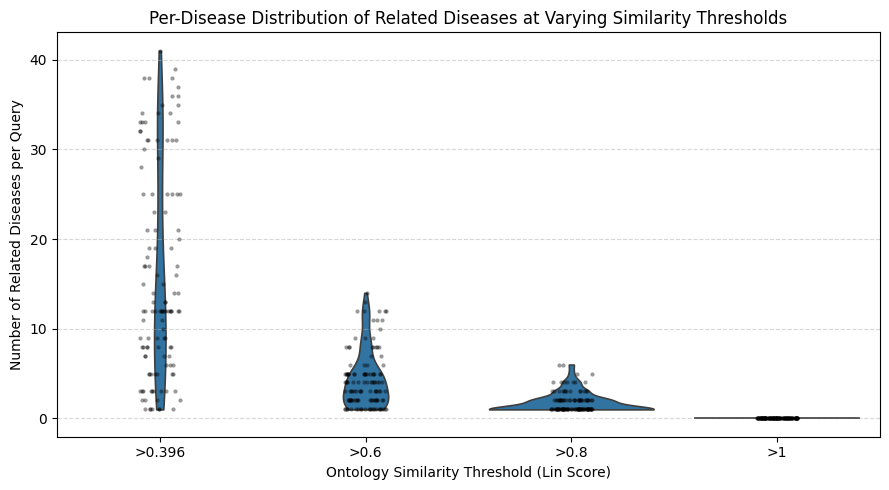

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for seaborn
lin_thrs = [0.396, 0.6, 0.8, 1]
n_positives = []
for lin_thr in lin_thrs:
    _n_positive = (m_lin_sim > lin_thr).sum(axis=1)
    n_positives.append(_n_positive)

# Flatten for seaborn: one row per data point
df_plot = pd.DataFrame({
    'Threshold': sum([[f'>{thr}'] * len(col) for thr, col in zip(lin_thrs, n_positives)], []),
    'N_Positives': np.concatenate(n_positives)
})

# Plot
plt.figure(figsize=(9, 5))
sns.violinplot(data=df_plot, x='Threshold', y='N_Positives', inner=None, cut=0, linewidth=1.2)
sns.stripplot(data=df_plot, x='Threshold', y='N_Positives', color='k', alpha=0.4, jitter=True, size=3)

# Aesthetics
plt.xlabel('Ontology Similarity Threshold (Lin Score)')
plt.ylabel('Number of Related Diseases per Query')
plt.title('Per-Disease Distribution of Related Diseases at Varying Similarity Thresholds')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [78]:
# imports
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# variables
avg = "micro"
lin_thrs = [1, 0.8, 0.6, 0.396]
data_dis_perf = list()

# functions
def precision_recall_set(y_true, y_pred_sets, N):

    precisions = list()
    recalls = list()

    for t, P in zip(y_true, y_pred_sets):
        P = set(P)

        if len(P) == 0:
            precisions.append(0.0)
            recalls.append(0.0)
            continue

        if t in P:
            precisions.append(1.0 / len(P))
            recalls.append(1.0)
        else:
            precisions.append(0.0)
            recalls.append(0.0)


    return float(np.mean(precisions)), float(np.mean(recalls))

# map predicted clusters to doid-labels!
pred_doid_lab_ts = [clust_to_enr.get(c) for c in test_pred_clusters]   # test doid labels!

pred_lin_ts = list()
for lab in pred_doid_lab_ts:
    pred_lin_ts.append([1 if d in lab  else 0 for d in dis_ord])
pred_lin_ts = np.array(pred_lin_ts)

# doid-label precision & recall
for lin_thr in lin_thrs:
    data_dis_perf.append({"lin_thr":lin_thr,
                          "roc_auc":f"{roc_auc_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "ap":f"{average_precision_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "precision":f"{precision_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "recall":f"{recall_score(lin_ts>=lin_thr, pred_lin_ts, average=avg):.3f}",
                          "hit":f"{recall_score(np.ones(len(df_test)), (pred_lin_ts & (lin_ts>=lin_thr)).sum(axis=1)>0):.3f}"})

df_dis_perf = pd.DataFrame(data_dis_perf)
df_dis_perf

,lin_thr,roc_auc,ap,precision,recall,hit
0,1.000,0.617,0.019,0.046,0.283,0.283
1,0.800,0.600,0.031,0.077,0.246,0.405
2,0.600,0.569,0.060,0.147,0.183,0.633
3,0.396,0.546,0.167,0.359,0.129,0.721


In [ ]:
from scipy.spatial.distance import cdist

metric = "cosine"

# Compute Similarity Matrices
# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(e_train, e_train, metric)

In [ ]:

precision_at_k_similarity(lin_ts, c_matrix_train)

In [80]:
len(lin_ts)

5248

In [77]:
# variables
avg = "micro"
lin_thrs = [1, 0.8, 0.6, 0.396]

data_rand_dis_perf = list()
for lin_thr in tqdm(lin_thrs):

    # store random performance
    rnd_roc_onehot = list()
    rnd_ap_oneshot = list()
    rnd_prec_onehot = list()
    rnd_rec_onehot = list()
    rnd_rec_hits = list()

    for i in range(100):
        rng = np.random.default_rng(i)
        _rnd_clust = rng.choice(clust_ord, size=len(df_test), replace=True)

        # map predicted clusters to doideudo-labels!
        _rnd_lab = [clust_to_enr.get(c) for c in _rnd_clust]   # test doideudo labels!

        _rnd_one_hot = list()
        for lab in _rnd_lab:
            _rnd_one_hot.append([1 if d in lab  else 0 for d in dis_ord])
        _rnd_one_hot = np.array( _rnd_one_hot)

        # multilabel
        _rnd_roc_auc = roc_auc_score(lin_ts>=lin_thr, _rnd_one_hot, average=avg)
        _onehot_prec = precision_score(lin_ts>=lin_thr,_rnd_one_hot, average=avg)
        _onehot_rec = recall_score(lin_ts>=lin_thr,_rnd_one_hot, average=avg)
        _rnd_hits = (_rnd_one_hot & (lin_ts>=lin_thr)).sum(axis=1)>0

        rnd_roc_onehot.append(_rnd_roc_auc)
        rnd_ap_oneshot.append(average_precision_score(lin_ts>=lin_thr, _rnd_one_hot, average=avg))
        rnd_prec_onehot.append(_onehot_prec)
        rnd_rec_onehot.append(_onehot_rec)
        rnd_rec_hits.append(recall_score(np.ones(len(df_test)), _rnd_hits))

    data_rand_dis_perf.append({"lin_thr":lin_thr,
                        "roc_auc":f"{np.mean(rnd_roc_onehot):.3f}",
                        "ap":f"{np.mean(rnd_ap_oneshot):.3f}",
                        "precision":f"{np.mean(rnd_prec_onehot):.3f}",
                        "recall":f"{np.mean(rnd_rec_onehot):.3f}",
                        "hit":f"{np.mean(rnd_rec_hits):.3f}"})


df_rand_dis_perf = pd.DataFrame(data_rand_dis_perf)
df_rand_dis_perf

100%|██████████| 4/4 [00:53<00:00, 13.28s/it]


,lin_thr,roc_auc,ap,precision,recall,hit
0,1.000,0.560,0.012,0.033,0.158,0.158
1,0.800,0.532,0.018,0.041,0.101,0.183
2,0.600,0.511,0.041,0.062,0.060,0.228
3,0.396,0.502,0.139,0.149,0.041,0.352


In [ ]:
with open("tmp/clust_to_enr.pkl", "wb") as f:
    pickle.dump(clust_to_enr, f)

In [ ]:
??pickle.dump

Signature:
pickle.dump(
    obj,
    file,
    protocol=None,
    *,
    fix_imports=True,
    buffer_callback=None,
)
Docstring:
Write a pickled representation of obj to the open file object file.

This is equivalent to ``Pickler(file, protocol).dump(obj)``, but may
be more efficient.

The optional *protocol* argument tells the pickler to use the given
protocol; supported protocols are 0, 1, 2, 3, 4 and 5.  The default
protocol is 4. It was introduced in Python 3.4, and is incompatible
with previous versions.

Specifying a negative protocol version selects the highest protocol
version supported.  The higher the protocol used, the more recent the
version of Python needed to read the pickle produced.

The *file* argument must have a write() method that accepts a single
bytes argument.  It can thus be a file object opened for binary
writing, an io.BytesIO instance, or any other custom object that meets
this interface.

If *fix_imports* is True and protocol is less than 3, pickle will try

In [ ]:
lift = df_dis_perf[["lin_thr", "hit"]].copy()
lift["rand_hit"] = df_rand_dis_perf["hit"]
lift["lift"] = lift["hit"].astype(float) / lift["rand_hit"].astype(float)
lift["lift"] = lift["lift"].round(1)
lift

,lin_thr,hit,rand_hit,lift
0,1.000,0.351,0.064,5.5
1,0.800,0.670,0.132,5.1
2,0.600,0.793,0.238,3.3
3,0.396,0.896,0.552,1.6


In [ ]:
pd.DataFrame(data_rand_dis_perf)

,lin_thr,roc_auc,ap,precision,recall,hit
0,1.000,0.495,0.008,0.007,0.064,0.064
1,0.800,0.500,0.019,0.019,0.075,0.132
2,0.600,0.496,0.055,0.050,0.067,0.238
3,0.396,0.498,0.199,0.190,0.071,0.552


## Batch Effect

In [19]:
import numpy as np
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

def evaluate_batch_effect(X_emb, cluster_labels, dataset_labels):
    """
    Evaluate batch effect mitigation and structure preservation.

    Parameters
    ----------
    X_emb : array-like, shape (n_samples, n_features)
        Embedding matrix.
    cluster_labels : array-like, shape (n_samples,)
        Cluster assignments.
    dataset_labels : array-like, shape (n_samples,)
        Dataset / batch labels.

    Returns
    -------
    dict
        Dictionary of computed metrics.
    """

    X_emb = np.asarray(X_emb)

    # --- Batch alignment metrics ---
    ari_batch = adjusted_rand_score(cluster_labels, dataset_labels)
    nmi_batch = normalized_mutual_info_score(cluster_labels, dataset_labels)

    # --- Silhouette scores ---
    sil_batch = silhouette_score(X_emb, dataset_labels, metric="cosine")
    sil_cluster = silhouette_score(X_emb, cluster_labels, metric="cosine")

    results = {
        "ARI_cluster_vs_dataset": ari_batch,
        "NMI_cluster_vs_dataset": nmi_batch,
        "Silhouette_batch_labels": sil_batch,
        "Silhouette_cluster_labels": sil_cluster,
    }

    return results


def print_interpretation(results):
    print("\n===== Batch Effect Evaluation =====")
    print(f"ARI (cluster vs dataset):      {results['ARI_cluster_vs_dataset']:.4f}  (↓ better)")
    print(f"NMI (cluster vs dataset):      {results['NMI_cluster_vs_dataset']:.4f}  (↓ better)")
    print(f"Silhouette (batch labels):     {results['Silhouette_batch_labels']:.4f}  (↓ better)")
    print(f"Silhouette (cluster labels):   {results['Silhouette_cluster_labels']:.4f}  (↑ better)")

    print("\nInterpretation:")
    print("- Low ARI/NMI → clusters independent of batch (good).")
    print("- Low silhouette(batch) → batches well mixed (good).")
    print("- High silhouette(cluster) → clusters well separated (good).")


In [22]:
e_train

array([[ 0.3450614 , -0.00581787,  0.38370562, ...,  0.09322482,
         0.26213428, -0.61238176],
       [-0.5431282 ,  0.49016404, -0.05322975, ...,  1.6745257 ,
        -0.94991165, -0.5936817 ],
       [-1.5224347 ,  0.0731235 , -2.3448267 , ...,  0.42670888,
        -1.2965732 , -1.247939  ],
       ...,
       [-0.30561137,  0.45858115,  0.21666986, ...,  0.8961776 ,
        -0.7887482 ,  1.0233165 ],
       [-0.11770959, -0.42838767, -0.47074428, ..., -0.4885714 ,
        -0.95087016,  0.24850048],
       [ 0.15374333,  0.55806065,  1.5291361 , ..., -1.8228902 ,
        -0.26506382,  0.9023059 ]], shape=(18305, 512), dtype=float32)

In [42]:
# all
print("ALL")
print_interpretation(evaluate_batch_effect(e_train, k_labels, df_train["dataset"].to_list()))

mask = np.array(df_train["doid_id"] == "Control", dtype=bool)

# only controls
print("CTRL")
print_interpretation(evaluate_batch_effect(e_train[mask], k_labels[mask], df_train["dataset"].to_numpy()[mask]))

# only diseases
print("DISEASES")
print_interpretation(evaluate_batch_effect(e_train[~mask], k_labels[~mask], df_train["dataset"].to_numpy()[~mask]))

ALL

===== Batch Effect Evaluation =====
ARI (cluster vs dataset):      0.0905  (↓ better)
NMI (cluster vs dataset):      0.5151  (↓ better)
Silhouette (batch labels):     0.1122  (↓ better)
Silhouette (cluster labels):   -0.1056  (↑ better)

Interpretation:
- Low ARI/NMI → clusters independent of batch (good).
- Low silhouette(batch) → batches well mixed (good).
- High silhouette(cluster) → clusters well separated (good).
CTRL

===== Batch Effect Evaluation =====
ARI (cluster vs dataset):      0.0722  (↓ better)
NMI (cluster vs dataset):      0.4958  (↓ better)
Silhouette (batch labels):     0.1762  (↓ better)
Silhouette (cluster labels):   -0.1545  (↑ better)

Interpretation:
- Low ARI/NMI → clusters independent of batch (good).
- Low silhouette(batch) → batches well mixed (good).
- High silhouette(cluster) → clusters well separated (good).
DISEASES

===== Batch Effect Evaluation =====
ARI (cluster vs dataset):      0.1156  (↓ better)
NMI (cluster vs dataset):      0.5400  (↓ better)

In [ ]:
# all
print("ALL")
print_interpretation(evaluate_batch_effect(e_train, k_labels, df_train["doid_id"].to_list()))

mask = np.array(df_train["doid_id"] == "Control", dtype=bool)

# only controls
print("CTRL")
print_interpretation(evaluate_batch_effect(e_train[mask], k_labels[mask], df_train["doid_id"].to_numpy()[mask]))

# only diseases
print("DISEASES")
print_interpretation(evaluate_batch_effect(e_train[~mask], k_labels[~mask], df_train["doid_id"].to_numpy()[~mask]))

In [45]:
print_interpretation(evaluate_batch_effect(e_train[~mask], k_labels[~mask], df_train["disease"].to_numpy()[~mask]))


===== Batch Effect Evaluation =====
ARI (cluster vs dataset):      0.1182  (↓ better)
NMI (cluster vs dataset):      0.4648  (↓ better)
Silhouette (batch labels):     -0.1387  (↓ better)
Silhouette (cluster labels):   -0.0792  (↑ better)

Interpretation:
- Low ARI/NMI → clusters independent of batch (good).
- Low silhouette(batch) → batches well mixed (good).
- High silhouette(cluster) → clusters well separated (good).


In [36]:
embeddings_train.shape

(18305, 512)

In [44]:
len(set(k_labels))

35

In [ ]:
e_train

(18305, 3501)

In [116]:
# all
print("ALL")
print_interpretation(evaluate_batch_effect(e_train, k_labels, df_train["dataset"].to_list()))

mask = np.array(df_train["doid_id"] == "Control", dtype=bool)

# only controls
print("CTRL")
print_interpretation(evaluate_batch_effect(e_train[mask], k_labels[mask], df_train["dataset"].to_numpy()[mask]))

# only diseases
print("DISEASES")
print_interpretation(evaluate_batch_effect(e_train[~mask], k_labels[~mask], df_train["dataset"].to_numpy()[~mask]))

ALL

===== Batch Effect Evaluation =====
ARI (cluster vs dataset):      0.5375  (↓ better)
NMI (cluster vs dataset):      0.7632  (↓ better)
Silhouette (batch labels):     0.2023  (↓ better)
Silhouette (cluster labels):   0.5047  (↑ better)

Interpretation:
- Low ARI/NMI → clusters independent of batch (good).
- Low silhouette(batch) → batches well mixed (good).
- High silhouette(cluster) → clusters well separated (good).
CTRL

===== Batch Effect Evaluation =====
ARI (cluster vs dataset):      0.4431  (↓ better)
NMI (cluster vs dataset):      0.7411  (↓ better)
Silhouette (batch labels):     0.2314  (↓ better)
Silhouette (cluster labels):   0.4340  (↑ better)

Interpretation:
- Low ARI/NMI → clusters independent of batch (good).
- Low silhouette(batch) → batches well mixed (good).
- High silhouette(cluster) → clusters well separated (good).
DISEASES

===== Batch Effect Evaluation =====
ARI (cluster vs dataset):      0.6226  (↓ better)
NMI (cluster vs dataset):      0.8013  (↓ better)
S

In [57]:
from sklearn.metrics import roc_auc_score

roc_auc_scores = list()
for dataset in tqdm(df_train["dataset"].unique()):
    print(f"Dataset: {dataset}")

    # get idxs control
    idxs = df_train.query("dataset==@dataset and doid_id=='Control'").index
    _e_ctrl = e_train[idxs]
    _k_ctrl = k_labels[idxs]

    if len(_e_ctrl) == 0:
        continue

    for doid in df_train.query("dataset==@dataset")["doid_id"].unique():
        if doid == "Control":
            continue
        idxs_doid = df_train.query("dataset==@dataset and doid_id==@doid").index
        if len(idxs_doid) <= 1:
            continue

        # get embeddings
        _e_dis = e_train[idxs_doid]
        _k_dis = k_labels[idxs_doid]


        # get similarity between control and disease
        sim_ctrl = cosine_similarity(_e_ctrl, _e_dis).flatten()
        sim_dis = cosine_similarity(_e_dis, _e_dis)[np.triu_indices(len(_e_dis), k=1)].flatten()

        y_sim = np.concatenate([sim_ctrl, sim_dis])
        y_gt = [0]*len(sim_ctrl) + [1]*len(sim_dis)

        # compute roc auc of cluster labels to separate control vs disease
        roc_auc = roc_auc_score(y_gt, y_sim)
        roc_auc_scores.append(roc_auc)

  1%|▏         | 6/471 [00:00<00:12, 36.11it/s]

Dataset: GSE86906
Dataset: GSE203346
Dataset: GSE137143
Dataset: GSE48812
Dataset: GSE52946
Dataset: TCGA-PRAD
Dataset: GSE193677


  3%|▎         | 16/471 [00:00<00:12, 37.48it/s]

Dataset: GSE106388
Dataset: GSE212384
Dataset: GSE84073
Dataset: GSE88805
Dataset: TCGA-LUAD
Dataset: TCGA-GBM
Dataset: GSE162632
Dataset: GSE199152
Dataset: GSE174302
Dataset: GSE129473
Dataset: TCGA-BLCA
Dataset: GSE89843
Dataset: GSE117769
Dataset: GSE125239
Dataset: GSE132401


  6%|▋         | 30/471 [00:00<00:08, 49.47it/s]

...

Dataset: GSE137619
Dataset: GSE165254
Dataset: GSE132699
Dataset: GSE211398
Dataset: GSE143143
Dataset: GSE128844
Dataset: GSE143953
Dataset: E-MTAB-7145
Dataset: GSE162691
Dataset: GSE163071
Dataset: GSE193193
Dataset: GSE159851
Dataset: GSE208781
Dataset: GSE145065
Dataset: GSE212613
Dataset: GSE207713
Dataset: GSE141836
Dataset: GSE207912
Dataset: GSE155067
Dataset: GSE104704
Dataset: GSE175839
Dataset: GSE222982
Dataset: GSE29006
Dataset: GSE87809
Dataset: GSE163526
Dataset: GSE67945
Dataset: GSE103152
Dataset: GSE100297
Dataset: GSE175764
Dataset: GSE180415
Dataset: GSE126169
Dataset: GSE85984
Dataset: GSE58933
Dataset: GSE124664
Dataset: GSE130049
Dataset: GSE151760
Dataset: GSE110914
Dataset: GSE169082
Dataset: GSE218494
Dataset: GSE113648


 97%|█████████▋| 459/471 [00:03<00:00, 198.58it/s]

Dataset: GSE212255
Dataset: GSE107871
Dataset: GSE106830
Dataset: GSE67333
Dataset: GSE53239
Dataset: GSE185064
Dataset: GSE142612
Dataset: GSE143979
Dataset: GSE159642
Dataset: GSE120836
Dataset: GSE165286
Dataset: GSE158558
Dataset: GSE151897
Dataset: GSE148387
Dataset: GSE124993
Dataset: GSE211358
Dataset: GSE130435
Dataset: GSE82340
Dataset: GSE149206
Dataset: GSE162828
Dataset: GSE140385
Dataset: GSE142591
Dataset: GSE71613
Dataset: GSE135623
Dataset: GSE184102
Dataset: GSE144576
Dataset: GSE120306
Dataset: GSE52249
Dataset: GSE155489
Dataset: GSE67812
Dataset: GSE150117
Dataset: GSE124335
Dataset: GSE148180
Dataset: GSE84684
Dataset: GSE226869
Dataset: GSE192755
Dataset: GSE140627
Dataset: GSE162712
Dataset: GSE189136
Dataset: GSE157978
Dataset: GSE208783
Dataset: GSE132215


100%|██████████| 471/471 [00:03<00:00, 145.51it/s]

Dataset: GSE141531
Dataset: GSE161989
Dataset: GSE203257
Dataset: GSE156657
Dataset: GSE221925
Dataset: GSE214987
Dataset: GSE69175


In [25]:
adata_train.obs

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease,celltype_id,sample_id,test_split_1
0,DSA07457.GSM2310211.Control,GSE86906,GSE86906,1064,289,DSA07457,Brain,19402,Control,Control,Schizophrenia,RNA-Seq,D,Control,Control,Control,0,GSM2310211,0
1,DSA05326.GSM6167423.Case,GSE203346,GSE203346,1194,320,DSA05326,Placenta,19402,Gestational Diabetes Mellitus,DOID:11714,Gestational Diabetes Mellitus,RNA-Seq,D,DOID:11714,DOID:11714,gestational diabetes,170,GSM6167423,0
2,DSA01224.GSM4071855.Control,GSE137143,GSE137143,204,62,DSA01224,nan,19402,Control,Control,Multiple Sclerosis,RNA-Seq,D,Control,Control,Control,0,GSM4071855,0
3,DSA05327.GSM6167363.Control,GSE203346,GSE203346,1194,320,DSA05327,Umbilical cord blood,19402,Control,Control,Gestational Diabetes Mellitus,RNA-Seq,D,Control,Control,Control,0,GSM6167363,0
4,DSA08056.GSM1185137.Case,GSE48812,GSE48812,2079,575,DSA08056,Prostate,19402,Prostate Cancer,DOID:10286,Prostate Cancer,RNA-Seq,D,DOID:10286,DOID:10286,prostate carcinoma,150,GSM1185137,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18300,DSA08794.GSM4247493.Case,GSE142987,GSE142987,923,252,DSA08794,nan,19402,Liver Cancer,DOID:684,Liver Cancer,RNA-Seq,D,DOID:684,DOID:684,hepatocellular carcinoma,14,GSM4247493,0
18301,DSA08970.TCGA-75-7030-01A.Case,TCGA-LUAD,TCGA-LUAD,502,146,DSA08970,nan,18983,Lung Adenocarcinoma,DOID:3910,Lung Adenocarcinoma,RNA-Seq,D,DOID:3910,DOID:3910,lung adenocarcinoma,85,TCGA-75-7030-01A,0
18302,DSA04386.GSM5690328.Case,GSE188799,GSE188799,2126,589,DSA04386,Adipose tissue,19402,Gestational Diabetes,DOID:11714,Gestational Diabetes,RNA-Seq,D,DOID:11714,DOID:11714,gestational diabetes,170,GSM5690328,0
18303,DSA06503.GSM1930372.Control,GSE74697,GSE74697,1739,474,DSA06503,Skin,19402,Control,Control,Psoriasis,RNA-Seq,D,Control,Control,Control,0,GSM1930372,0


In [59]:
np.mean(roc_auc_scores)

np.float64(0.6634582267720677)

<Axes: >

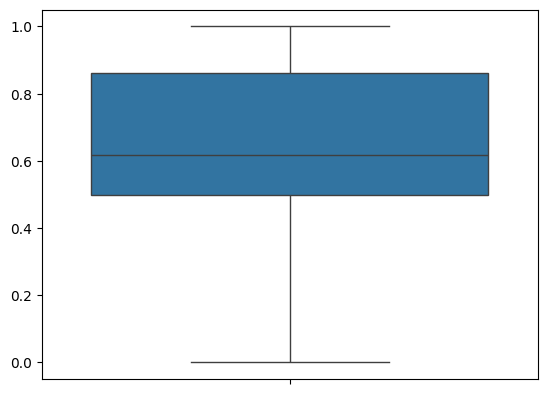

In [55]:
sns.boxplot(roc_auc_scores)

In [50]:
np.mean(roc_auc_scores)

np.float64(nan)

In [53]:
roc_auc_scores

[0.4630196523053666,
 0.49344773971966954,
 0.49137119432110343,
 1.0,
 0.46964285714285714,
 0.8626122962280085,
 0.43315963240715083,
 0.6660335549224439,
 0.5439391762452107,
 0.7397959183673469,
 0.5714285714285714,
 0.9411764705882353,
 0.7717647058823529,
 0.9923529411764705,
 0.9205882352941177,
 0.9205882352941177,
 0.9541176470588235,
 0.9884936496672384,
 0.9992471702959036,
 0.9902681901959078,
 1.0,
 0.7364178947624742,
 0.7750284682508226,
 0.44771241830065356,
 0.7592312645222699,
 0.5557403208196858,
 0.542474358974359,
 0.9036683381496379,
 0.5470240722170866,
 0.5188139921641041,
 0.5034013605442177,
 0.4864367220664913,
 0.40277777777777773,
 0.8600000000000001,
 0.8819553427502864,
 0.9492935635792779,
 0.502154964506467,
 0.507352533839613,
 0.5422567175018156,
 0.9999329732874855,
 1.0,
 0.5141689561562804,
 0.5682959464777646,
 0.5415823592943457,
 0.5376184790899745,
 0.578787284144427,
 0.5448890965085298,
 0.5378157063916298,
 0.978053614786185,
 0.986752873563

In [41]:
sim_dis

array([0.9239217 , 0.9648306 , 0.8294281 , 0.95943546, 0.7751626 ,
       0.9023695 , 0.85316765, 0.7346575 , 0.9768435 , 0.9164264 ,
       0.92702734, 0.91558933, 0.86760485, 0.8208543 , 0.85420144,
       0.87292683, 0.9521586 , 0.876102  , 0.8806693 , 0.8896671 ,
       0.87741715, 0.83276165, 0.88683754, 0.77062917, 0.9303392 ,
       0.9109824 , 0.8112887 , 0.93233263, 0.9561008 , 0.9566127 ,
       0.9486214 , 0.9173323 , 0.7872447 , 0.92063004, 0.9437315 ,
       0.8469542 , 0.9235847 , 0.94289035, 0.8832637 , 0.7948793 ,
       0.9374129 , 0.73277473, 0.83741426, 0.8149822 , 0.7099779 ,
       0.9409578 , 0.8593603 , 0.8570875 , 0.83135545, 0.83083475,
       0.7909745 , 0.8135595 , 0.8164171 , 0.9510457 , 0.82348853,
       0.79332626, 0.83035463, 0.7678    , 0.9174853 , 0.8447597 ,
       0.8520069 , 0.79146063, 0.84187424, 0.8542838 , 0.85137177,
       0.8154671 , 0.86983275, 0.9111134 , 0.85516524, 0.88566065,
       0.7338835 , 0.8556107 , 0.79181325, 0.8282757 , 0.74610

<function sklearn.metrics.pairwise.cosine_similarity(X, Y=None, dense_output=True)>

In [25]:
mask.sum()

np.int64(6482)

In [ ]:
(df_train["doid_id"] == "control")

0        False
1        False
2        False
3        False
4        False
         ...  
11818    False
11819    False
11820    False
11821    False
11822    False
Name: doid_id, Length: 11823, dtype: bool

In [ ]:
mask

False

In [ ]:
len(k_labels)

11823

In [ ]:
len(embeddings_train)

18305

# Junkyard

In [ ]:
precision_score(Y_top_ts, ts_one_hot, average="macro")
# recall_score(Y_top_ts, ts_one_hot, average="micro") n

NameError: name 'Y_top_ts' is not defined

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, average_precision_score
print(precision_score(Y_top_ts, ts_one_hot, average="micro"))
print(recall_score(Y_top_ts, ts_one_hot, average="micro"))
print(roc_auc_score(Y_top_ts, ts_one_hot))
print(average_precision_score(Y_top_ts, ts_one_hot))

0.33554590267948653
0.7001731337203381
0.7017308492476263
0.21492743368278


In [ ]:
print(recall_score(Y_top_ts, ts_one_hot, average="micro"))

0.7001731337203381


In [ ]:
print(roc_auc_score(Y_top_ts, ts_one_hot, average="macro"))

0.7017308492476263


In [ ]:
Y_top_ts.sum(axis=0)

array([ 266,   73,  335,   70, 2692,  110,   11, 1117,  244,  448,  154,
       1094,  467, 1014,  107,  231,  562,  546,  278])

In [ ]:
[(t, doid_to_term.get(t)) for t in top_level]

[('DOID:630', 'genetic disease'),
 ('DOID:0014667', 'disease of metabolism'),
 ('DOID:0050117', 'disease by infectious agent'),
 ('DOID:150', 'disease of mental health'),
 ('DOID:14566', 'disease of cellular proliferation'),
 ('DOID:225', 'syndrome'),
 ('DOID:0080015', 'physical disorder'),
 ('DOID:77', 'gastrointestinal system disease'),
 ('DOID:1287', 'cardiovascular system disease'),
 ('DOID:1579', 'respiratory system disease'),
 ('DOID:18', 'urinary system disease'),
 ('DOID:2914', 'immune system disease'),
 ('DOID:74', 'hematopoietic system disease'),
 ('DOID:863', 'nervous system disease'),
 ('DOID:0060118', 'thoracic disease'),
 ('DOID:16', 'integumentary system disease'),
 ('DOID:28', 'endocrine system disease'),
 ('DOID:17', 'musculoskeletal system disease'),
 ('DOID:15', 'reproductive system disease')]

In [ ]:
# AUROC per class (one-vs-rest)
auroc_per_class = []
for j in range(n_classes):
    y_true_j = onehot_ts[:, j]
    y_pred_j = _rand_one_hot[:, j]   # or your real predictions
    auroc_per_class.append(
        roc_auc_score(y_true_j, y_pred_j) if len(np.unique(y_true_j)) > 1 else np.nan
    )

auroc_per_class = np.array(auroc_per_class)
auroc_per_class

array([0.50765864, 0.49431788, 0.48947828, 0.48959431, 0.49640669,
       0.49859305, 0.46808886, 0.49263865, 0.49705796, 0.49659785,
       0.50064418, 0.50868024, 0.49526432, 0.49357739, 0.52323543,
       0.48751362, 0.50865375, 0.51761283, 0.49089173])

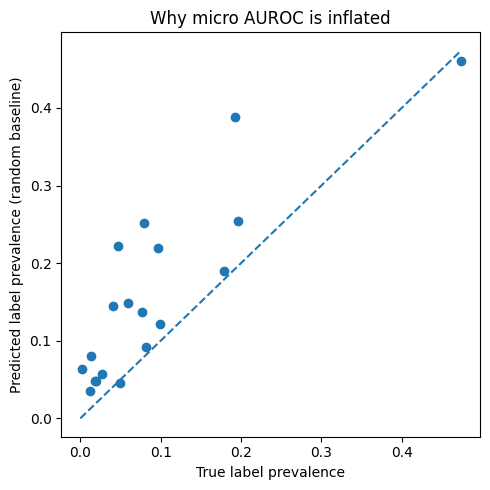

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# True prevalence per label
true_prev = onehot_ts.mean(axis=0)

# Predicted prevalence per label (random baseline)
pred_prev = _rand_one_hot.mean(axis=0)

plt.figure(figsize=(5, 5))
plt.scatter(true_prev, pred_prev)
plt.plot([0, true_prev.max()], [0, true_prev.max()], linestyle="--")

plt.xlabel("True label prevalence")
plt.ylabel("Predicted label prevalence (random baseline)")
plt.title("Why micro AUROC is inflated")

plt.tight_layout()
plt.show()


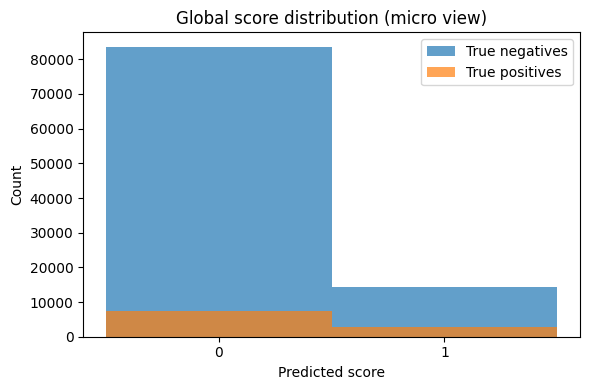

In [ ]:
# Flatten all label decisions
y_true_flat = onehot_ts.flatten()
y_pred_flat = _rand_one_hot.flatten()

plt.figure(figsize=(6, 4))

plt.hist(y_pred_flat[y_true_flat == 0], bins=[-0.5, 0.5, 1.5],
         alpha=0.7, label="True negatives")
plt.hist(y_pred_flat[y_true_flat == 1], bins=[-0.5, 0.5, 1.5],
         alpha=0.7, label="True positives")

plt.xticks([0, 1])
plt.xlabel("Predicted score")
plt.ylabel("Count")
plt.legend()
plt.title("Global score distribution (micro view)")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score

# Shuffle labels independently (destroys prevalence alignment)
rng = np.random.default_rng(0)
shuffled = onehot_ts.copy()
rng.shuffle(shuffled, axis=0)

print("Micro AUROC (cluster-random):",
      roc_auc_score(onehot_ts, _rand_one_hot, average="micro"))

print("Micro AUROC (fully shuffled):",
      roc_auc_score(onehot_ts, shuffled, average="micro"))


Micro AUROC (cluster-random): 0.5622060681130808
Micro AUROC (fully shuffled): 0.5693469023125874


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ps_lab_ts: list of true single labels (e.g. [34, 9, 50, ...])
# pred_ps_lab_ts: list of lists (multilabel predictions)

# 1) Binarize into multilabel indicator matrices
mlb = MultiLabelBinarizer()

# True labels must be wrapped as lists
Y_true = mlb.fit_transform([[y] for y in ps_lab_ts])
Y_pred = mlb.transform(pred_ps_lab_ts)

# 2) Build a MICRO confusion matrix by flattening
y_true_flat = Y_true.ravel()
y_pred_flat = Y_pred.ravel()

cm = confusion_matrix(y_true_flat, y_pred_flat)
cm = confusion_matrix(onehot_ts, pred_onehot_ts)

# 3) Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
plt.tight_layout()
plt.show()


ValueError: multilabel-indicator is not supported

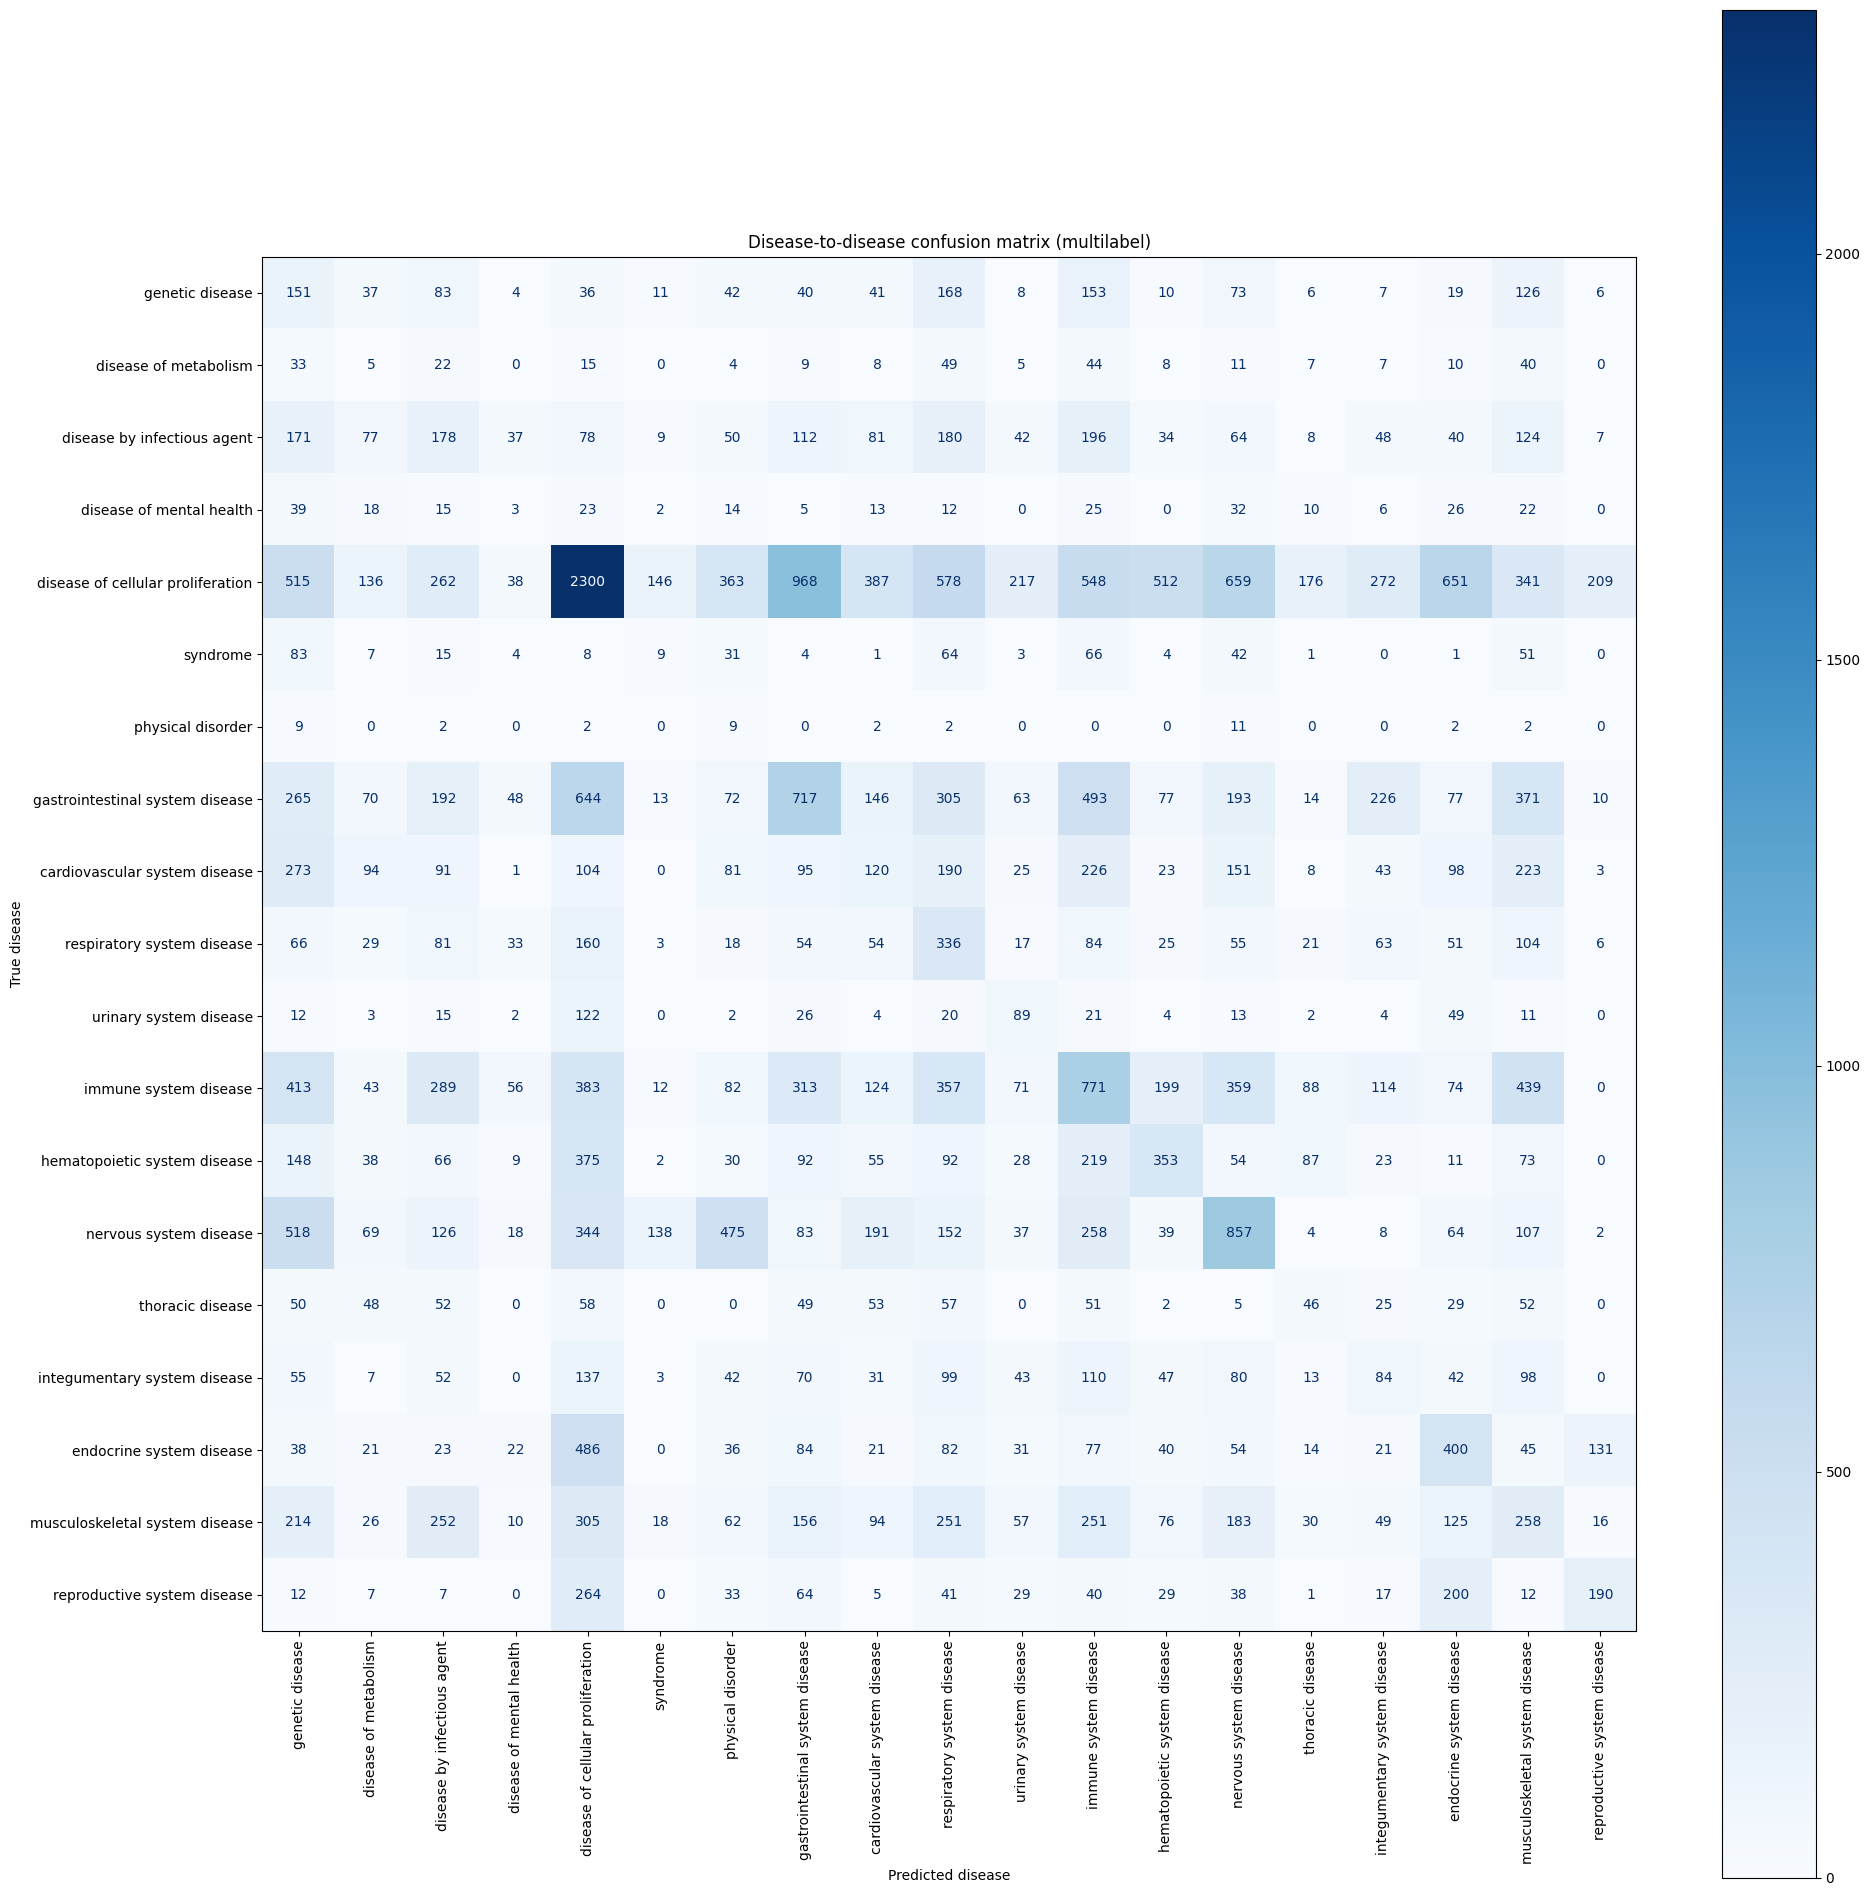

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# onehot_ts: (n_samples, N) true binary matrix
# pred_onehot_ts: (n_samples, N) predicted binary matrix

N = onehot_ts.shape[1]

# Build N x N confusion-like matrix
# rows = true label index
# cols = predicted label index
cm = np.zeros((N, N), dtype=int)

for i in range(onehot_ts.shape[0]):
    true_idx = np.where(onehot_ts[i] == 1)[0]
    pred_idx = np.where(pred_onehot_ts[i] == 1)[0]

    for t in true_idx:
        for p in pred_idx:
            cm[t, p] += 1

# Plot
fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[doid_to_term.get(d) for d in top_doid_terms])
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=90)

ax.set_xlabel("Predicted disease")
ax.set_ylabel("True disease")
ax.set_title("Disease-to-disease confusion matrix (multilabel)")

plt.tight_layout()
plt.show()


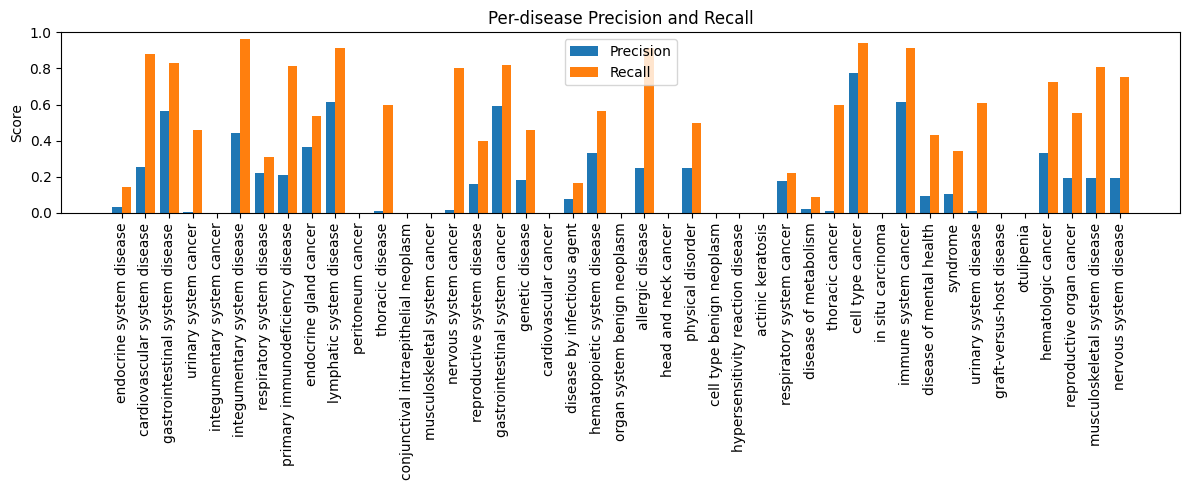

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# onehot_ts: (n_samples, N) true binary matrix
# pred_onehot_ts: (n_samples, N) predicted binary matrix
# doid_list: list of length N (column names)

N = onehot_ts.shape[1]

# Per-label precision and recall
precision = np.zeros(N)
recall = np.zeros(N)

for j in range(N):
    y_true = onehot_ts[:, j]
    y_pred = pred_onehot_ts[:, j]

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision[j] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall[j] = tp / (tp + fn) if (tp + fn) > 0 else 0.0

# Bar plot
x = np.arange(N)
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, precision, width, label="Precision")
ax.bar(x + width/2, recall, width, label="Recall")

ax.set_xticks(x)
ax.set_xticklabels([doid_to_term.get(d) for d in top_doid_terms], rotation=90)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Per-disease Precision and Recall")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
onehot_ts

array([[0, 0, 0, ..., 1, 0, 1],
       [0, 0, 0, ..., 1, 0, 1],
       [0, 0, 0, ..., 1, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5683, 19))

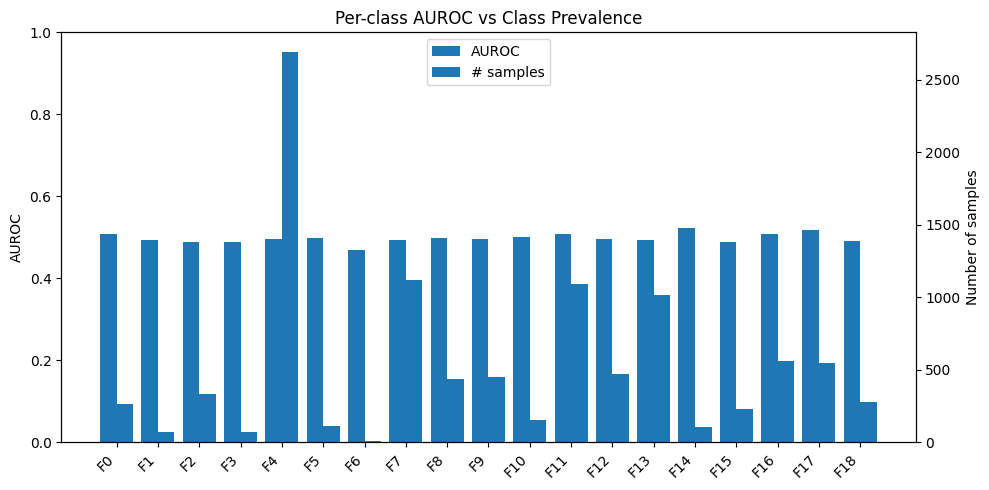

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

n_classes = onehot_ts.shape[1]

# AUROC per class (one-vs-rest)
auroc_per_class = []
for j in range(n_classes):
    y_true_j = onehot_ts[:, j]
    y_pred_j = _rand_one_hot[:, j]   # or your real predictions
    auroc_per_class.append(
        roc_auc_score(y_true_j, y_pred_j) if len(np.unique(y_true_j)) > 1 else np.nan
    )

auroc_per_class = np.array(auroc_per_class)

# Number of samples per class
n_samples_per_class = onehot_ts.sum(axis=0)


import matplotlib.pyplot as plt

x = np.arange(n_classes)
width = 0.4

fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: AUROC
bars1 = ax1.bar(
    x - width/2,
    auroc_per_class,
    width,
    label="AUROC",
)
ax1.set_ylabel("AUROC")
ax1.set_ylim(0, 1)

# Right axis: number of samples
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x + width/2,
    n_samples_per_class,
    width,
    label="# samples",
)
ax2.set_ylabel("Number of samples")

# X axis
ax1.set_xticks(x)
ax1.set_xticklabels(
    family_names if "family_names" in locals() else [f"F{i}" for i in x],
    rotation=45,
    ha="right",
)

# Title
ax1.set_title("Per-class AUROC vs Class Prevalence")

# Legends (combine both axes)
handles = bars1 + bars2
labels = ["AUROC", "# samples"]
ax1.legend(handles, labels, loc="upper center")

plt.tight_layout()
plt.show()


In [ ]:
print(recall_score(Y_top_ts, _rand_one_hot, average="micro"))

0.27334759140442


In [ ]:
rng = np.random.default_rng(0)
perm = rng.permutation(ts_one_hot.shape[0])
_ts_one_hot_shuff = ts_one_hot[perm]

print(recall_score(Y_top_ts, _ts_one_hot_shuff, average="micro"))

0.3158162745697118


In [ ]:
_ts_one_hot_shuff

array([[0, 1, 0, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1],
       ...,
       [0, 1, 0, ..., 1, 0, 0],
       [0, 1, 0, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]], shape=(5683, 8))

In [ ]:
_ts_one_hot_shuff

In [ ]:
def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)


n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{df_train["doid_id"].nunique()}'
_n_uniq_dis = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_uniq_dis.mean():.1f}±{_n_uniq_dis.std():.1f}"
_n_clust = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust.mean():.1f}±{_n_clust.std():.1f}"


# nº of unique disease
n_uniq_dis = f'{df_k_enrich["disease"].nunique()}/{df_train["doid_id"].nunique()}'
n_uniq_enr = f'{df_k_enrich_sig["disease"].nunique()}/{df_train["doid_id"].nunique()}'

# nº of diseases per cluster
_n_dis_per_clust = df_k_enrich.groupby("cluster")["disease"].nunique()
n_dis_per_clust = f"{_n_dis_per_clust.mean():.1f}±{_n_dis_per_clust.std():.1f}"

_n_enr_per_clust = df_k_enrich_sig.groupby("cluster")["disease"].nunique()
n_enr_per_clust = f"{_n_enr_per_clust.mean():.1f}±{_n_enr_per_clust.std():.1f}"

# nº if cluster per disease
_n_clust_per_dis = df_k_enrich.groupby("disease")["cluster"].nunique()
n_clust_per_dis = f"{_n_clust_per_dis.mean():.1f}±{_n_clust_per_dis.std():.1f}"

_n_clust_per_enr = df_k_enrich_sig.groupby("disease")["cluster"].nunique()
n_clust_per_enr = f"{_n_clust_per_enr.mean():.1f}±{_n_clust_per_enr.std():.1f}"

# mask ENRICHED DISEASES
mask = list()
for i in tqdm(range(len(df_train))):
    label_i = k_labels[i]
    dis_i = df_train["doid_id"].to_list()[i]

    # is this disease ENRICHED in this cluster?
    if dis_i in clust_to_enr.get(label_i):
        mask.append(True)
    else:
        mask.append(False)

print(f"Nº of masked diseases {np.sum(mask)}")
true_labels = np.array(df_train["doid_id"].to_list())
k_labels = np.array(k_labels)

# store in datafram
df_k_res = pd.DataFrame(
    [
        {
            "Clustering": "k",
            "Nº Samples": len(k_labels),
            "Nº Clusters": len(set(k_labels)),
            "Max Cluster Size": max(Counter(k_labels).values()),
            "Silhouette": f'{silhouette_score(e_train,k_labels.astype(int), metric="cosine"):.3f}',
            "Cluster Purity": f"{cluster_purity(true_labels, k_labels):.3}",
            "Nº unique Enriched Diseases": n_uniq_dis,
            "Nº Dis. per Clust.": n_dis_per_clust,
            "Nº Clust. per Enr.": n_clust_per_dis,
            
        },
        {
            "Clustering": "k-enriched",
            "Nº Samples": len(k_labels[mask]),
            "Nº Clusters": len(set(k_labels[mask])),
            "Max Cluster Size": max(Counter(k_labels[mask]).values()),
            "Silhouette": f'{silhouette_score(e_train[mask],k_labels.astype(int)[mask], metric="cosine"):.3f}',
            "Cluster Purity": f'{cluster_purity(true_labels[mask],k_labels[mask]):.3}',
            "Nº unique Enriched Diseases": n_uniq_enr,
            "Nº Dis. per Clust.": n_enr_per_clust,
            "Nº Clust. per Enr.": n_clust_per_enr,
        }


    ]
)

df_k_res

In [ ]:
for ic_thr in [1.0, 0.8, 0.6, 0.396]:

    # Build multilabel ground truth under this IC threshold
    y_true = ut.get_multilabel_y(df_split, dis_ord, rel_map, thr_related=ic_thr)

    # AUROC & AP (correct order)
    auroc = roc_auc_score(y_true, y_pred)
    ap = average_precision_score(y_true, y_pred)
    random = y_true.sum() / y_true.size
    # top-k precision & recall
    prec_k = {f"Prec@{k}": get_precision_at_k(y_pred, y_true, k) for k in eval_k}
    recall_k = {f"Recall@{k}": get_recall_at_k(y_pred, y_true, k) for k in eval_k}

    # all-top-score precision & recall
    prec_top = get_precision_at_top_score(y_pred, y_true)
    recall_top = get_recall_at_top_score(y_pred, y_true)
    size_clust = [sum(y == max(y)) for y in y_pred]

In [ ]:
lin_ts = np.array([doid_to_lin[d] for d in df_test["doid_id"]])
print("Shape lin_ts", lin_ts.shape)

Shape lin_ts (3611, 123)


In [ ]:
# imports
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# variables
avg = "micro"
lin_thr = 1

# functions
def precision_recall_set(y_true, y_pred_sets, N):

    precisions = list()
    recalls = list()

    for t, P in zip(y_true, y_pred_sets):
        P = set(P)

        if len(P) == 0:
            precisions.append(0.0)
            recalls.append(0.0)
            continue

        if t in P:
            precisions.append(1.0 / len(P))
            recalls.append(1.0)
        else:
            precisions.append(0.0)
            recalls.append(0.0)


    return float(np.mean(precisions)), float(np.mean(recalls))

# map predicted clusters to doideudo-labels!
pred_doid_lab_ts = [clust_to_enr.get(c) for c in test_pred_clusters]   # test doideudo labels!

# map doideudo-labels to broad doid terms one hot encodings!
pred_lin_ts = list()
for doid_lab in pred_doid_lab_ts:
    _one_hot = list()
    for doid_i in doid_lab:
        _one_hot.append(doid_to_lin[doid_i]>=lin_thr)
    
    # merge one hot encoding into a single one!
    _one_hot = np.array(_one_hot)
    pred_lin_ts.append(_one_hot.sum(axis=0).astype(bool).astype(int))

pred_lin_ts = np.array(pred_lin_ts)

# doideudo-label precision & recall
prec_doid, rec_doid = precision_recall_set(df_test["doid_id"].to_list(), pred_doid_lab_ts, N = df_test["doid_id"].nunique())

print("ROC AUC multilabel", roc_auc_score(lin_ts>=lin_thr, pred_lin_ts, average=avg))
print("Precision multilabel", precision_score(lin_ts>=lin_thr, pred_lin_ts, average=avg))
print("Recall multilabel", recall_score(lin_ts>=lin_thr, pred_lin_ts, average=avg))
print("Average Precision multilabel", average_precision_score(lin_ts>=lin_thr, pred_lin_ts, average=avg))
print("Precision doid", np.mean(prec_doid))
print("Recall doid", np.mean(rec_doid))


# binary
_hits_ts = (pred_lin_ts & (lin_ts>=lin_thr)).sum(axis=1)>0
print("Hits Recall", recall_score(np.ones(len(df_test)), _hits_ts))

ROC AUC multilabel 0.6069296457545478
Precision multilabel 0.035559534467323184
Recall multilabel 0.27499307671005263
Average Precision multilabel 0.01567299101954594
Precision doid 0.040555347670081635
Recall doid 0.27499307671005263
Hits Recall 0.27499307671005263


In [ ]:
Counter(k_labels)

Counter({np.int32(18): 721,
         np.int32(15): 706,
         np.int32(13): 597,
         np.int32(4): 522,
         np.int32(11): 520,
         np.int32(2): 509,
         np.int32(8): 473,
         np.int32(1): 452,
         np.int32(43): 327,
         np.int32(22): 321,
         np.int32(29): 318,
         np.int32(7): 293,
         np.int32(3): 274,
         np.int32(9): 262,
         np.int32(5): 231,
         np.int32(46): 215,
         np.int32(21): 212,
         np.int32(16): 210,
         np.int32(19): 207,
         np.int32(52): 192,
         np.int32(28): 190,
         np.int32(35): 188,
         np.int32(36): 187,
         np.int32(10): 186,
         np.int32(47): 185,
         np.int32(50): 181,
         np.int32(6): 174,
         np.int32(14): 173,
         np.int32(20): 171,
         np.int32(49): 157,
         np.int32(48): 156,
         np.int32(37): 151,
         np.int32(0): 148,
         np.int32(34): 145,
         np.int32(41): 142,
         np.int32(51): 141,
  

In [ ]:
def get_precision_at_top_score(y_pred, y_true, zero_division:int=0):
    """
    Precision where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    precisions = []

    for i in range(N):
        # highest score in this sample
        max_score = y_pred[i].max()

        if max_score == 0:
            if zero_division is not None:
                precisions.append(zero_division)
                continue


        # all labels tied for highest score
        top_idxs = np.where(y_pred[i] == max_score)[0]

        # true positives among these
        tp = y_true[i, top_idxs].sum()

        # precision for this sample
        precisions.append(tp / len(top_idxs))

    return np.mean(precisions)

get_precision_at_top_score(pred_lin_ts, lin_ts>=lin_thr)

np.float64(0.5312096004228047)

In [ ]:
# ROC AUC multilabel 0.6977163105542787
# Precision multilabel 0.18497794652925476
# Recall multilabel 0.5314550524934383
# Precision doid 0.011896204546379734
# Recall doid 0.1509277208529493
# Hits Recall 0.46607587925782334

In [ ]:
"""ROC AUC multilabel 0.6967505615680019
Precision multilabel 0.24020679649345075
Recall multilabel 0.48207841207349084
Precision doid 0.035664524206297156
Recall doid 0.17695929105510938
Hits Recall 0.677097756854057"""

'ROC AUC multilabel 0.6967505615680019\nPrecision multilabel 0.24020679649345075\nRecall multilabel 0.48207841207349084\nPrecision doid 0.035664524206297156\nRecall doid 0.17695929105510938\nHits Recall 0.677097756854057'

In [ ]:
# variables
avg = "micro"
lin_thr = 0.8

# store rndom performance
rnd_roc_onehot = list()
rnd_ap_oneshot = list()
rnd_prec_onehot = list()
rnd_rec_onehot = list()
rnd_prec_doid = list()
rnd_rec_doid = list()

rnd_prec_hits = list()
rnd_rec_hits = list()

for i in range(100):
    rng = np.random.default_rng(i)
    _rnd_clust = rng.choice(clust_ord, size=len(df_test), replace=True)

    # map predicted clusters to doideudo-labels!
    _rnd_lab = [clust_to_enr.get(c) for c in _rnd_clust]   # test doideudo labels!

    # map doideudo-labels to broad doid terms one hot encodings!
    _rnd_one_hot = list()
    for doid_lab in _rnd_lab:
        _rnd_one_hot_i = list()
        for doid_i in doid_lab:
            _rnd_one_hot_i.append(doid_to_lin[doid_i]>lin_thr)
        
        # merge one hot encoding into a single one!
        _rnd_one_hot_i = np.array(_rnd_one_hot_i)
        _rnd_one_hot.append(_rnd_one_hot_i.sum(axis=0).astype(bool).astype(int))

    _rnd_one_hot = np.array(_rnd_one_hot)

    # multilabel
    _rnd_roc_auc = roc_auc_score(lin_ts>lin_thr, _rnd_one_hot, average=avg)
    _onehot_prec = precision_score(lin_ts>lin_thr,_rnd_one_hot, average=avg)
    _onehot_rec = recall_score(lin_ts>lin_thr,_rnd_one_hot, average=avg)
    rnd_ap_oneshot.append(average_precision_score(lin_ts>=lin_thr, pred_lin_ts, average=avg))
    # binary
    _rnd_hits = (_rnd_one_hot & (lin_ts>lin_thr)).sum(axis=1)>0
    rnd_prec_hits.append(precision_score(np.ones(len(df_test)), _rnd_hits))
    rnd_rec_hits.append(recall_score(np.ones(len(df_test)), _rnd_hits))


    # multiclass
    _rnd_prec_doid, _rnd_recall_doid = precision_recall_set(df_test["doid_id"].to_list(), _rnd_lab, N = df_test["doid_id"].nunique())

    rnd_roc_onehot.append(_rnd_roc_auc)
    rnd_prec_onehot.append(_onehot_prec)
    rnd_rec_onehot.append(_onehot_rec)
    rnd_prec_doid.append(_rnd_prec_doid)
    rnd_rec_doid.append(_rnd_recall_doid)

print("Random AUROC onehot", np.mean(rnd_roc_onehot))
print("Random Precision onehot", np.mean(rnd_prec_onehot))
print("Random Recall onehot", np.mean(rnd_rec_onehot))
print("Average Precision multilabel", np.mean(rnd_ap_oneshot))
print("Random Precisions doid", np.mean(rnd_prec_doid))
print("Random Recalls doid", np.mean(rnd_rec_doid))

print("Random Hits Recision", np.mean(rnd_prec_hits))
print("Random Hits Recall", np.mean(rnd_rec_hits))

Random AUROC onehot 0.5132447426451763
Random Precision onehot 0.027316825523243816
Random Recall onehot 0.08589743589743587
Average Precision multilabel 0.044715878042203956
Random Precisions doid 0.005618271818779326
Random Recalls doid 0.03656604818609803
Random Hits Recision 1.0
Random Hits Recall 0.07736361118803656


In [ ]:
((_rnd_one_hot & (lin_ts>lin_thr)).sum(axis=1)>0)

array([False, False, False, ..., False,  True, False], shape=(3611,))

In [ ]:
lin_thr = 0.396

sum(_rnd_one_hot[200][(lin_ts>lin_thr)[200]])>0

np.False_

In [ ]:
((_rnd_one_hot & (lin_ts>lin_thr)).sum(axis=1)>0)

array([False, False, False, ..., False,  True, False], shape=(3611,))

In [ ]:
lin_thr = 0.396

sum(_rnd_one_hot[200][(lin_ts>lin_thr)[200]])>0

np.False_

In [ ]:
((_rnd_one_hot & (lin_ts>lin_thr)).sum(axis=1)>0)

array([False, False, False, ..., False,  True, False], shape=(3611,))

In [ ]:
lin_thr = 0.396

sum(_rnd_one_hot[200][(lin_ts>lin_thr)[200]])>0

np.False_